In [63]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import sklearn.linear_model

In [64]:
import math
import sys

In [65]:
url = "https://github.com/EpistasisLab/pmlb/raw/refs/heads/master/datasets/560_bodyfat/560_bodyfat.tsv.gz"
df = pd.read_csv(url, sep="\t", compression="gzip")
df.sample(n=10)

,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,target
226,1.0650,55.0,169.50,68.25,37.2,101.7,91.1,97.1,56.6,38.5,22.6,33.4,29.3,18.8,14.8
224,1.0740,55.0,179.75,68.75,41.1,106.9,95.3,98.2,57.4,37.1,21.8,34.1,31.1,19.2,10.9
231,1.0620,57.0,182.25,71.75,39.4,103.4,96.7,100.7,59.3,38.6,22.8,31.8,29.1,19.0,16.1
239,1.0316,65.0,189.75,65.75,40.8,106.4,100.5,100.5,59.2,38.1,24.0,35.9,30.5,19.1,29.9
207,1.0254,47.0,195.00,72.50,40.2,102.7,101.3,101.7,60.7,39.4,23.3,36.7,31.6,18.4,32.8
8,1.0900,25.0,191.00,74.00,38.1,100.9,82.5,99.9,62.9,38.3,23.8,35.9,31.1,18.2,4.1
44,1.0814,39.0,125.25,68.00,31.5,85.1,76.0,88.2,50.0,34.7,21.0,26.1,23.1,16.1,7.7
102,1.0530,41.0,172.75,71.25,36.3,96.7,89.2,98.3,60.0,38.4,23.2,31.0,29.2,18.4,20.1
199,1.0462,43.0,170.75,67.50,37.4,103.7,89.7,94.2,58.5,39.0,24.1,33.8,28.8,18.8,23.6
154,1.0510,27.0,200.25,73.50,38.2,101.1,100.1,105.0,62.1,40.0,24.9,33.7,29.2,19.4,21.0



BODY MEASUREMENTS SUMMARY


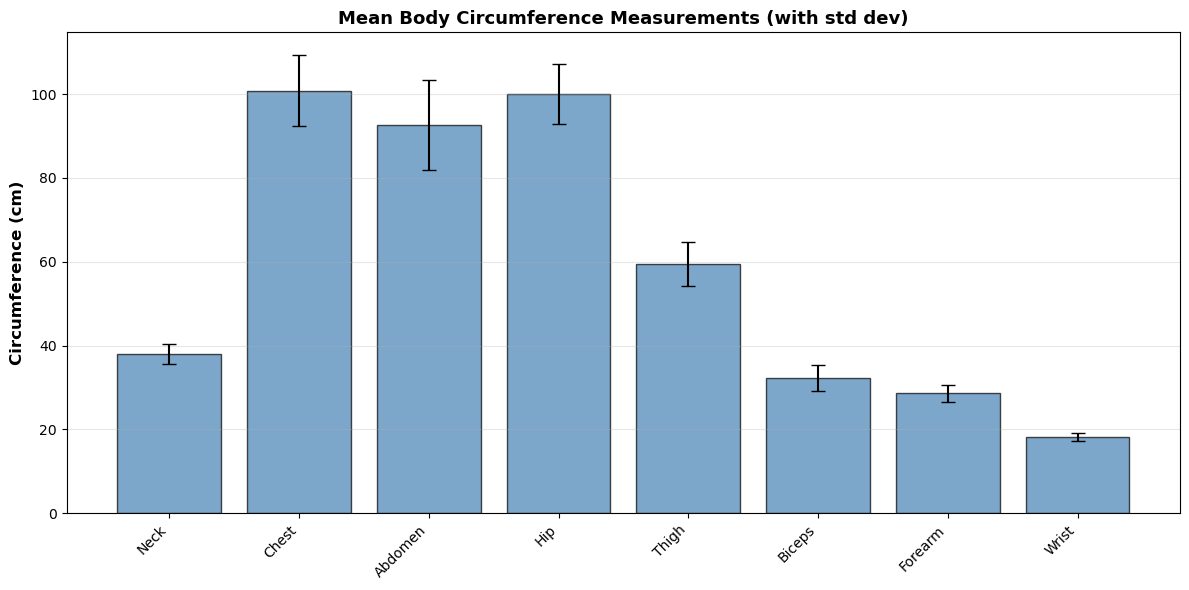


EDA COMPLETE - Review the charts above


In [ ]:
# YOUR CODE HERE
# ============================================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================================

# ============================================================================
# 1. DISTRIBUTION ANALYSIS - Histograms for all numeric columns
# ============================================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols






print("\n" + "=" * 80)
print("EDA COMPLETE - Review the charts above")
print("=" * 80)



**Explanations for the 3 highlighted charts:**

**Chart 1: Abdomen vs Body Fat %**
- **Why it's interesting:** Abdomen circumference has the strongest correlation with body fat percentage. The scatter plot shows a clear positive linear trend, making it a strong single-feature predictor.
- **Noteworthy:** The relationship is nearly linear, with minimal outliers. Color-coding by age shows that age doesn't strongly confound this relationship. This suggests abdomen measurement alone could be a powerful predictor.

**Chart 2: Body Fat Distribution by Age Groups**
- **Why it's interesting:** Shows how body fat percentage varies across different age groups, revealing potential age-related patterns.
- **Noteworthy:** The box plots and histograms reveal that older age groups tend to have higher median body fat percentages, but there's significant overlap and variability within each group. This suggests age is a factor but not the primary driver.

**Chart 3: Correlation Heatmap of Key Features**
- **Why it's interesting:** Provides a visual summary of how all key features relate to each other and to the target, helping identify multicollinearity and feature importance.
- **Noteworthy:** Density shows a very strong negative correlation with body fat (expected, as higher density means lower body fat). Abdomen, Chest, and Hip measurements are highly correlated with each other and with the target, suggesting they capture similar information about body composition.

Copy these code blocks into your notebook and run them. The first block performs the full EDA, and the second block creates the 3 highlighted charts with explanations.

In [67]:
# YOUR CODE HERE
# ============================================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================================

# Set pandas display options to show more content
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows (or set to a number like 50)
pd.set_option('display.width', None)        # Auto-detect width
pd.set_option('display.max_colwidth', None) # Show full column content
pd.set_option('display.precision', 4)        # Set decimal precision

# Basic information about the dataset
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Missing values - formatted nicely
print("\n" + "-" * 80)
print("MISSING VALUES PER COLUMN")
print("-" * 80)
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum().values / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0]  # Only show columns with missing values
if len(missing_df) > 0:
    display(missing_df.style.background_gradient(subset=['Missing %'], cmap='Reds'))
else:
    print("✓ No missing values found!")

# Data types - formatted nicely
print("\n" + "-" * 80)
print("DATA TYPES")
print("-" * 80)
dtypes_df = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.count().values
})
display(dtypes_df.style.set_properties(**{'text-align': 'left'}))

# Basic statistics - using display() for better formatting
print("\n" + "-" * 80)
print("BASIC STATISTICS")
print("-" * 80)
display(df.describe().style.format('{:.4f}').background_gradient(cmap='Blues', axis=0))

# Additional summary statistics
print("\n" + "-" * 80)
print("ADDITIONAL SUMMARY")
print("-" * 80)
summary_data = {
    'Column': df.select_dtypes(include=[np.number]).columns,
    'Mean': df.select_dtypes(include=[np.number]).mean().values,
    'Median': df.select_dtypes(include=[np.number]).median().values,
    'Std Dev': df.select_dtypes(include=[np.number]).std().values,
    'Min': df.select_dtypes(include=[np.number]).min().values,
    'Max': df.select_dtypes(include=[np.number]).max().values,
    'Range': (df.select_dtypes(include=[np.number]).max() - 
              df.select_dtypes(include=[np.number]).min()).values
}
summary_df = pd.DataFrame(summary_data)
display(summary_df.style.format({
    'Mean': '{:.4f}',
    'Median': '{:.4f}',
    'Std Dev': '{:.4f}',
    'Min': '{:.4f}',
    'Max': '{:.4f}',
    'Range': '{:.4f}'
}).background_gradient(subset=['Mean', 'Std Dev'], cmap='YlOrRd'))

DATASET OVERVIEW
Shape: 252 rows × 15 columns

Total missing values: 0

--------------------------------------------------------------------------------
MISSING VALUES PER COLUMN
--------------------------------------------------------------------------------
✓ No missing values found!

--------------------------------------------------------------------------------
DATA TYPES
--------------------------------------------------------------------------------


,Column,Data Type,Non-Null Count
0,Density,float64,252
1,Age,float64,252
2,Weight,float64,252
3,Height,float64,252
4,Neck,float64,252
5,Chest,float64,252
6,Abdomen,float64,252
7,Hip,float64,252
8,Thigh,float64,252
9,Knee,float64,252



--------------------------------------------------------------------------------
BASIC STATISTICS
--------------------------------------------------------------------------------


,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,target
count,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000
mean,1.0556,44.8849,178.9244,70.1488,37.9921,100.8242,92.5560,99.9048,59.4060,38.5905,23.1024,32.2734,28.6639,18.2298,19.1508
std,0.0190,12.6020,29.3892,3.6629,2.4309,8.4305,10.7831,7.1641,5.2500,2.4118,1.6949,3.0213,2.0207,0.9336,8.3687
min,0.9950,22.0000,118.5000,29.5000,31.1000,79.3000,69.4000,85.0000,47.2000,33.0000,19.1000,24.8000,21.0000,15.8000,0.0000
25%,1.0414,35.7500,159.0000,68.2500,36.4000,94.3500,84.5750,95.5000,56.0000,36.9750,22.0000,30.2000,27.3000,17.6000,12.4750
50%,1.0549,43.0000,176.5000,70.0000,38.0000,99.6500,90.9500,99.3000,59.0000,38.5000,22.8000,32.0500,28.7000,18.3000,19.2000
75%,1.0704,54.0000,197.0000,72.2500,39.4250,105.3750,99.3250,103.5250,62.3500,39.9250,24.0000,34.3250,30.0000,18.8000,25.3000
max,1.1089,81.0000,363.1500,77.7500,51.2000,136.2000,148.1000,147.7000,87.3000,49.1000,33.9000,45.0000,34.9000,21.4000,47.5000



--------------------------------------------------------------------------------
ADDITIONAL SUMMARY
--------------------------------------------------------------------------------


,Column,Mean,Median,Std Dev,Min,Max,Range
0,Density,1.0556,1.0549,0.0190,0.9950,1.1089,0.1139
1,Age,44.8849,43.0000,12.6020,22.0000,81.0000,59.0000
2,Weight,178.9244,176.5000,29.3892,118.5000,363.1500,244.6500
3,Height,70.1488,70.0000,3.6629,29.5000,77.7500,48.2500
4,Neck,37.9921,38.0000,2.4309,31.1000,51.2000,20.1000
5,Chest,100.8242,99.6500,8.4305,79.3000,136.2000,56.9000
6,Abdomen,92.5560,90.9500,10.7831,69.4000,148.1000,78.7000
7,Hip,99.9048,99.3000,7.1641,85.0000,147.7000,62.7000
8,Thigh,59.4060,59.0000,5.2500,47.2000,87.3000,40.1000
9,Knee,38.5905,38.5000,2.4118,33.0000,49.1000,16.1000



DISTRIBUTION ANALYSIS


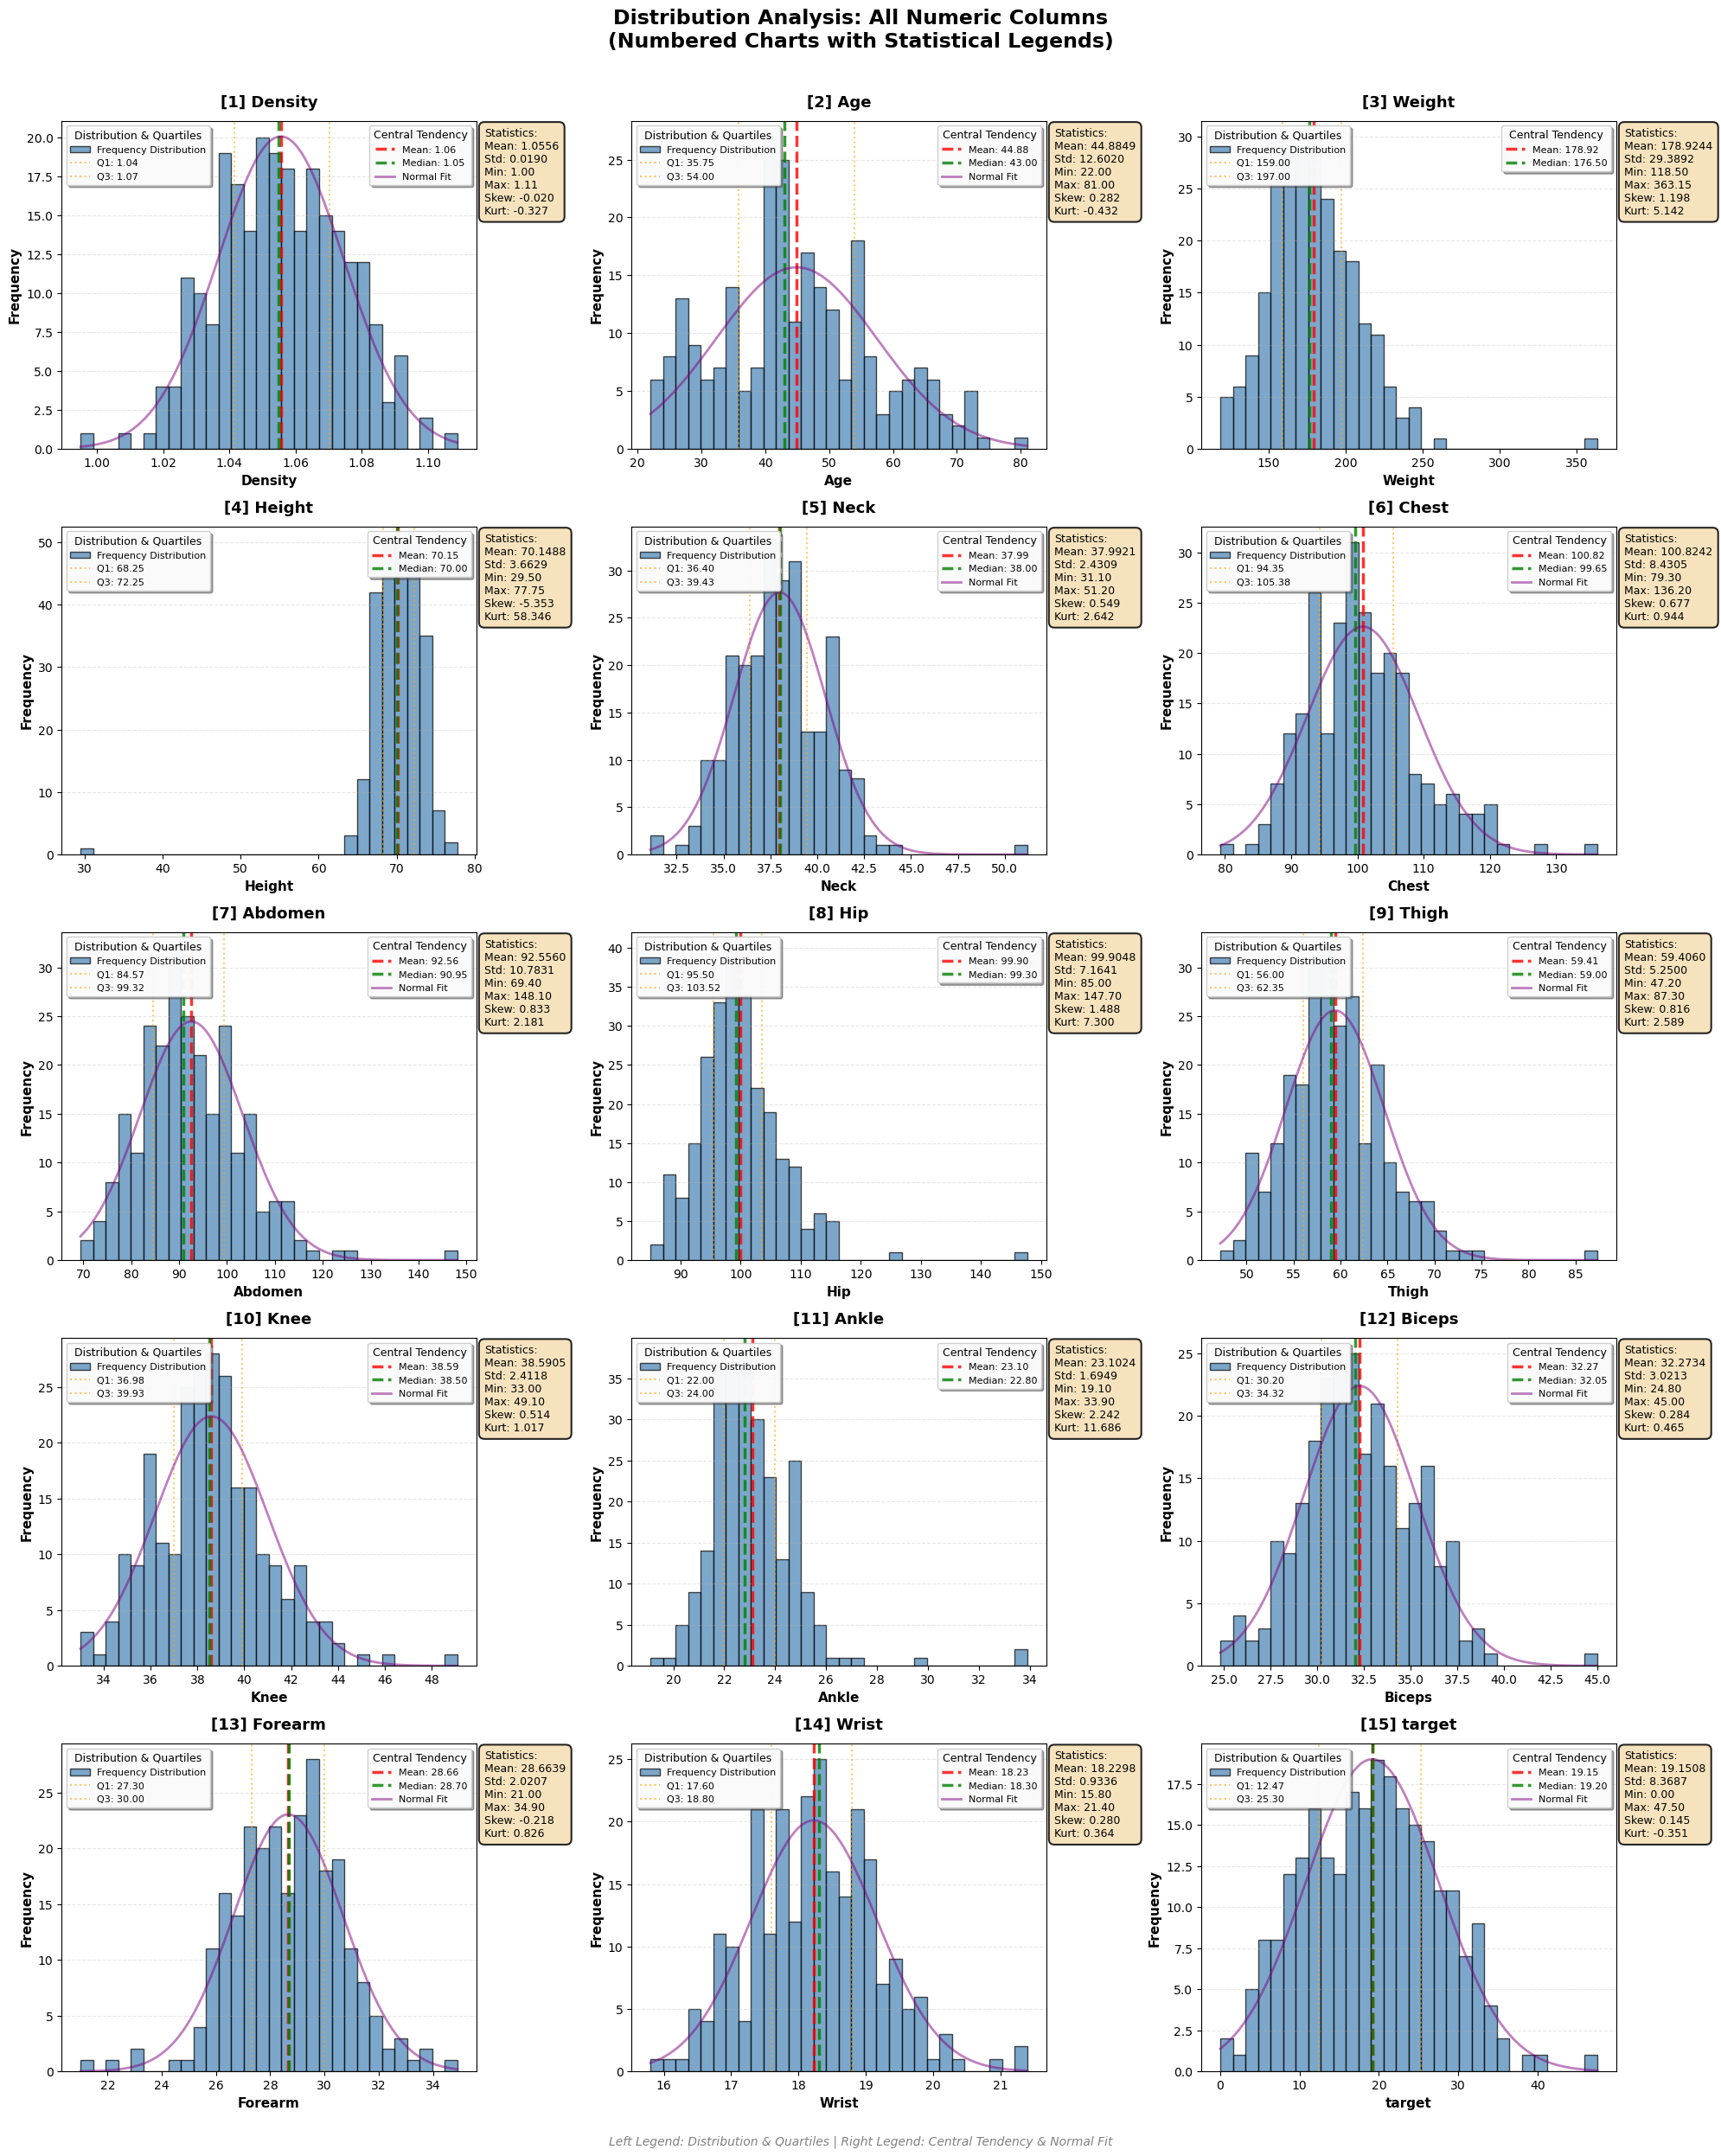


--------------------------------------------------------------------------------
DISTRIBUTION SUMMARY TABLE
--------------------------------------------------------------------------------


,Column,Mean,Std Dev,Min,Max,Skewness,Kurtosis
0,Density,1.0556,0.0190,1.00,1.11,-0.020,-0.327
1,Age,44.8849,12.6020,22.00,81.00,0.282,-0.432
2,Weight,178.9244,29.3892,118.50,363.15,1.198,5.142
3,Height,70.1488,3.6629,29.50,77.75,-5.353,58.346
4,Neck,37.9921,2.4309,31.10,51.20,0.549,2.642
5,Chest,100.8242,8.4305,79.30,136.20,0.677,0.944
6,Abdomen,92.5560,10.7831,69.40,148.10,0.833,2.181
7,Hip,99.9048,7.1641,85.00,147.70,1.488,7.300
8,Thigh,59.4060,5.2500,47.20,87.30,0.816,2.589
9,Knee,38.5905,2.4118,33.00,49.10,0.514,1.017


In [68]:
# ============================================================================
# 1. DISTRIBUTION ANALYSIS - Histograms for all numeric columns
# ============================================================================
print("\n" + "=" * 80)
print("DISTRIBUTION ANALYSIS")
print("=" * 80)

numeric_cols = df.select_dtypes(include=[np.number]).columns
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    
    # Calculate comprehensive statistics
    mean_val = data.mean()
    median_val = data.median()
    std_val = data.std()
    min_val = data.min()
    max_val = data.max()
    q25 = data.quantile(0.25)
    q75 = data.quantile(0.75)
    skewness = scipy.stats.skew(data)
    kurtosis = scipy.stats.kurtosis(data)
    
    # Create histogram
    n, bins, patches = axes[i].hist(data, bins=30, edgecolor='black', alpha=0.7, 
                                    color='steelblue')
    
    # Add vertical lines for key statistics
    mean_line = axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2.5, 
                    alpha=0.8, label=f'Mean: {mean_val:.2f}')
    median_line = axes[i].axvline(median_val, color='green', linestyle='--', linewidth=2.5, 
                    alpha=0.8, label=f'Median: {median_val:.2f}')
    q25_line = axes[i].axvline(q25, color='orange', linestyle=':', linewidth=1.5, 
                    alpha=0.6, label=f'Q1: {q25:.2f}')
    q75_line = axes[i].axvline(q75, color='orange', linestyle=':', linewidth=1.5, 
                    alpha=0.6, label=f'Q3: {q75:.2f}')
    
    # Add normal distribution overlay for reference (if data looks normal)
    norm_line = None
    if abs(skewness) < 1:  # Only if roughly symmetric
        x_norm = np.linspace(min_val, max_val, 100)
        y_norm = scipy.stats.norm.pdf(x_norm, mean_val, std_val) * len(data) * (bins[1] - bins[0])
        norm_line = axes[i].plot(x_norm, y_norm, 'purple', linestyle='-', linewidth=2, 
                    alpha=0.5, label='Normal Fit')[0]
    
    # Set title with number badge integrated (before title text)
    title_text = f'[{i+1}] {col}'
    axes[i].set_title(title_text, fontsize=13, fontweight='bold', pad=12)
    
    # Set labels
    axes[i].set_xlabel(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3, axis='y', linestyle='--')
    
    # Add comprehensive statistics box (top right, outside plot area)
    stats_text = (f'Statistics:\n'
                  f'Mean: {mean_val:.4f}\n'
                  f'Std: {std_val:.4f}\n'
                  f'Min: {min_val:.2f}\n'
                  f'Max: {max_val:.2f}\n'
                  f'Skew: {skewness:.3f}\n'
                  f'Kurt: {kurtosis:.3f}')
    
    axes[i].text(1.02, 0.98, stats_text, transform=axes[i].transAxes,
                fontsize=9, verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85, 
                         edgecolor='black', linewidth=1.5, pad=0.5))
    
    # Create two separate legends - LEFT and RIGHT
    # LEFT legend: Distribution shape and quartiles
    left_handles = [
        plt.Rectangle((0,0),1,1, facecolor='steelblue', alpha=0.7, edgecolor='black'),
        q25_line,
        q75_line
    ]
    left_labels = ['Frequency Distribution', f'Q1: {q25:.2f}', f'Q3: {q75:.2f}']
    
    # RIGHT legend: Central tendency measures
    right_handles = [mean_line, median_line]
    right_labels = [f'Mean: {mean_val:.2f}', f'Median: {median_val:.2f}']
    
    if norm_line is not None:
        right_handles.append(norm_line)
        right_labels.append('Normal Fit')
    
    # Position legends on opposite sides
    left_legend = axes[i].legend(left_handles, left_labels, 
                                loc='upper left', fontsize=8, framealpha=0.95, 
                                fancybox=True, shadow=True, title='Distribution & Quartiles',
                                title_fontsize=9)
    right_legend = axes[i].legend(right_handles, right_labels, 
                                 loc='upper right', fontsize=8, framealpha=0.95, 
                                 fancybox=True, shadow=True, title='Central Tendency',
                                 title_fontsize=9)
    
    # Re-add left legend (matplotlib removes previous when adding new)
    axes[i].add_artist(left_legend)

# Hide extra subplots
for i in range(len(numeric_cols), len(axes)):
    axes[i].axis('off')

# Add overall title
plt.suptitle('Distribution Analysis: All Numeric Columns\n(Numbered Charts with Statistical Legends)', 
             fontsize=17, fontweight='bold', y=0.998)

# Add footer with legend explanation
fig.text(0.5, 0.01, 
         'Left Legend: Distribution & Quartiles | Right Legend: Central Tendency & Normal Fit',
         ha='center', fontsize=10, style='italic', color='gray')

plt.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.show()

# Print summary table
print("\n" + "-" * 80)
print("DISTRIBUTION SUMMARY TABLE")
print("-" * 80)
summary_stats = []
for col in numeric_cols:
    data = df[col].dropna()
    summary_stats.append({
        'Column': col,
        'Mean': data.mean(),
        'Std Dev': data.std(),
        'Min': data.min(),
        'Max': data.max(),
        'Skewness': scipy.stats.skew(data),
        'Kurtosis': scipy.stats.kurtosis(data)
    })
summary_df = pd.DataFrame(summary_stats)
display(summary_df.style.format({
    'Mean': '{:.4f}',
    'Std Dev': '{:.4f}',
    'Min': '{:.2f}',
    'Max': '{:.2f}',
    'Skewness': '{:.3f}',
    'Kurtosis': '{:.3f}'
}).background_gradient(subset=['Skewness'], cmap='RdYlGn', vmin=-2, vmax=2))


OUTLIER DETECTION - Box Plots


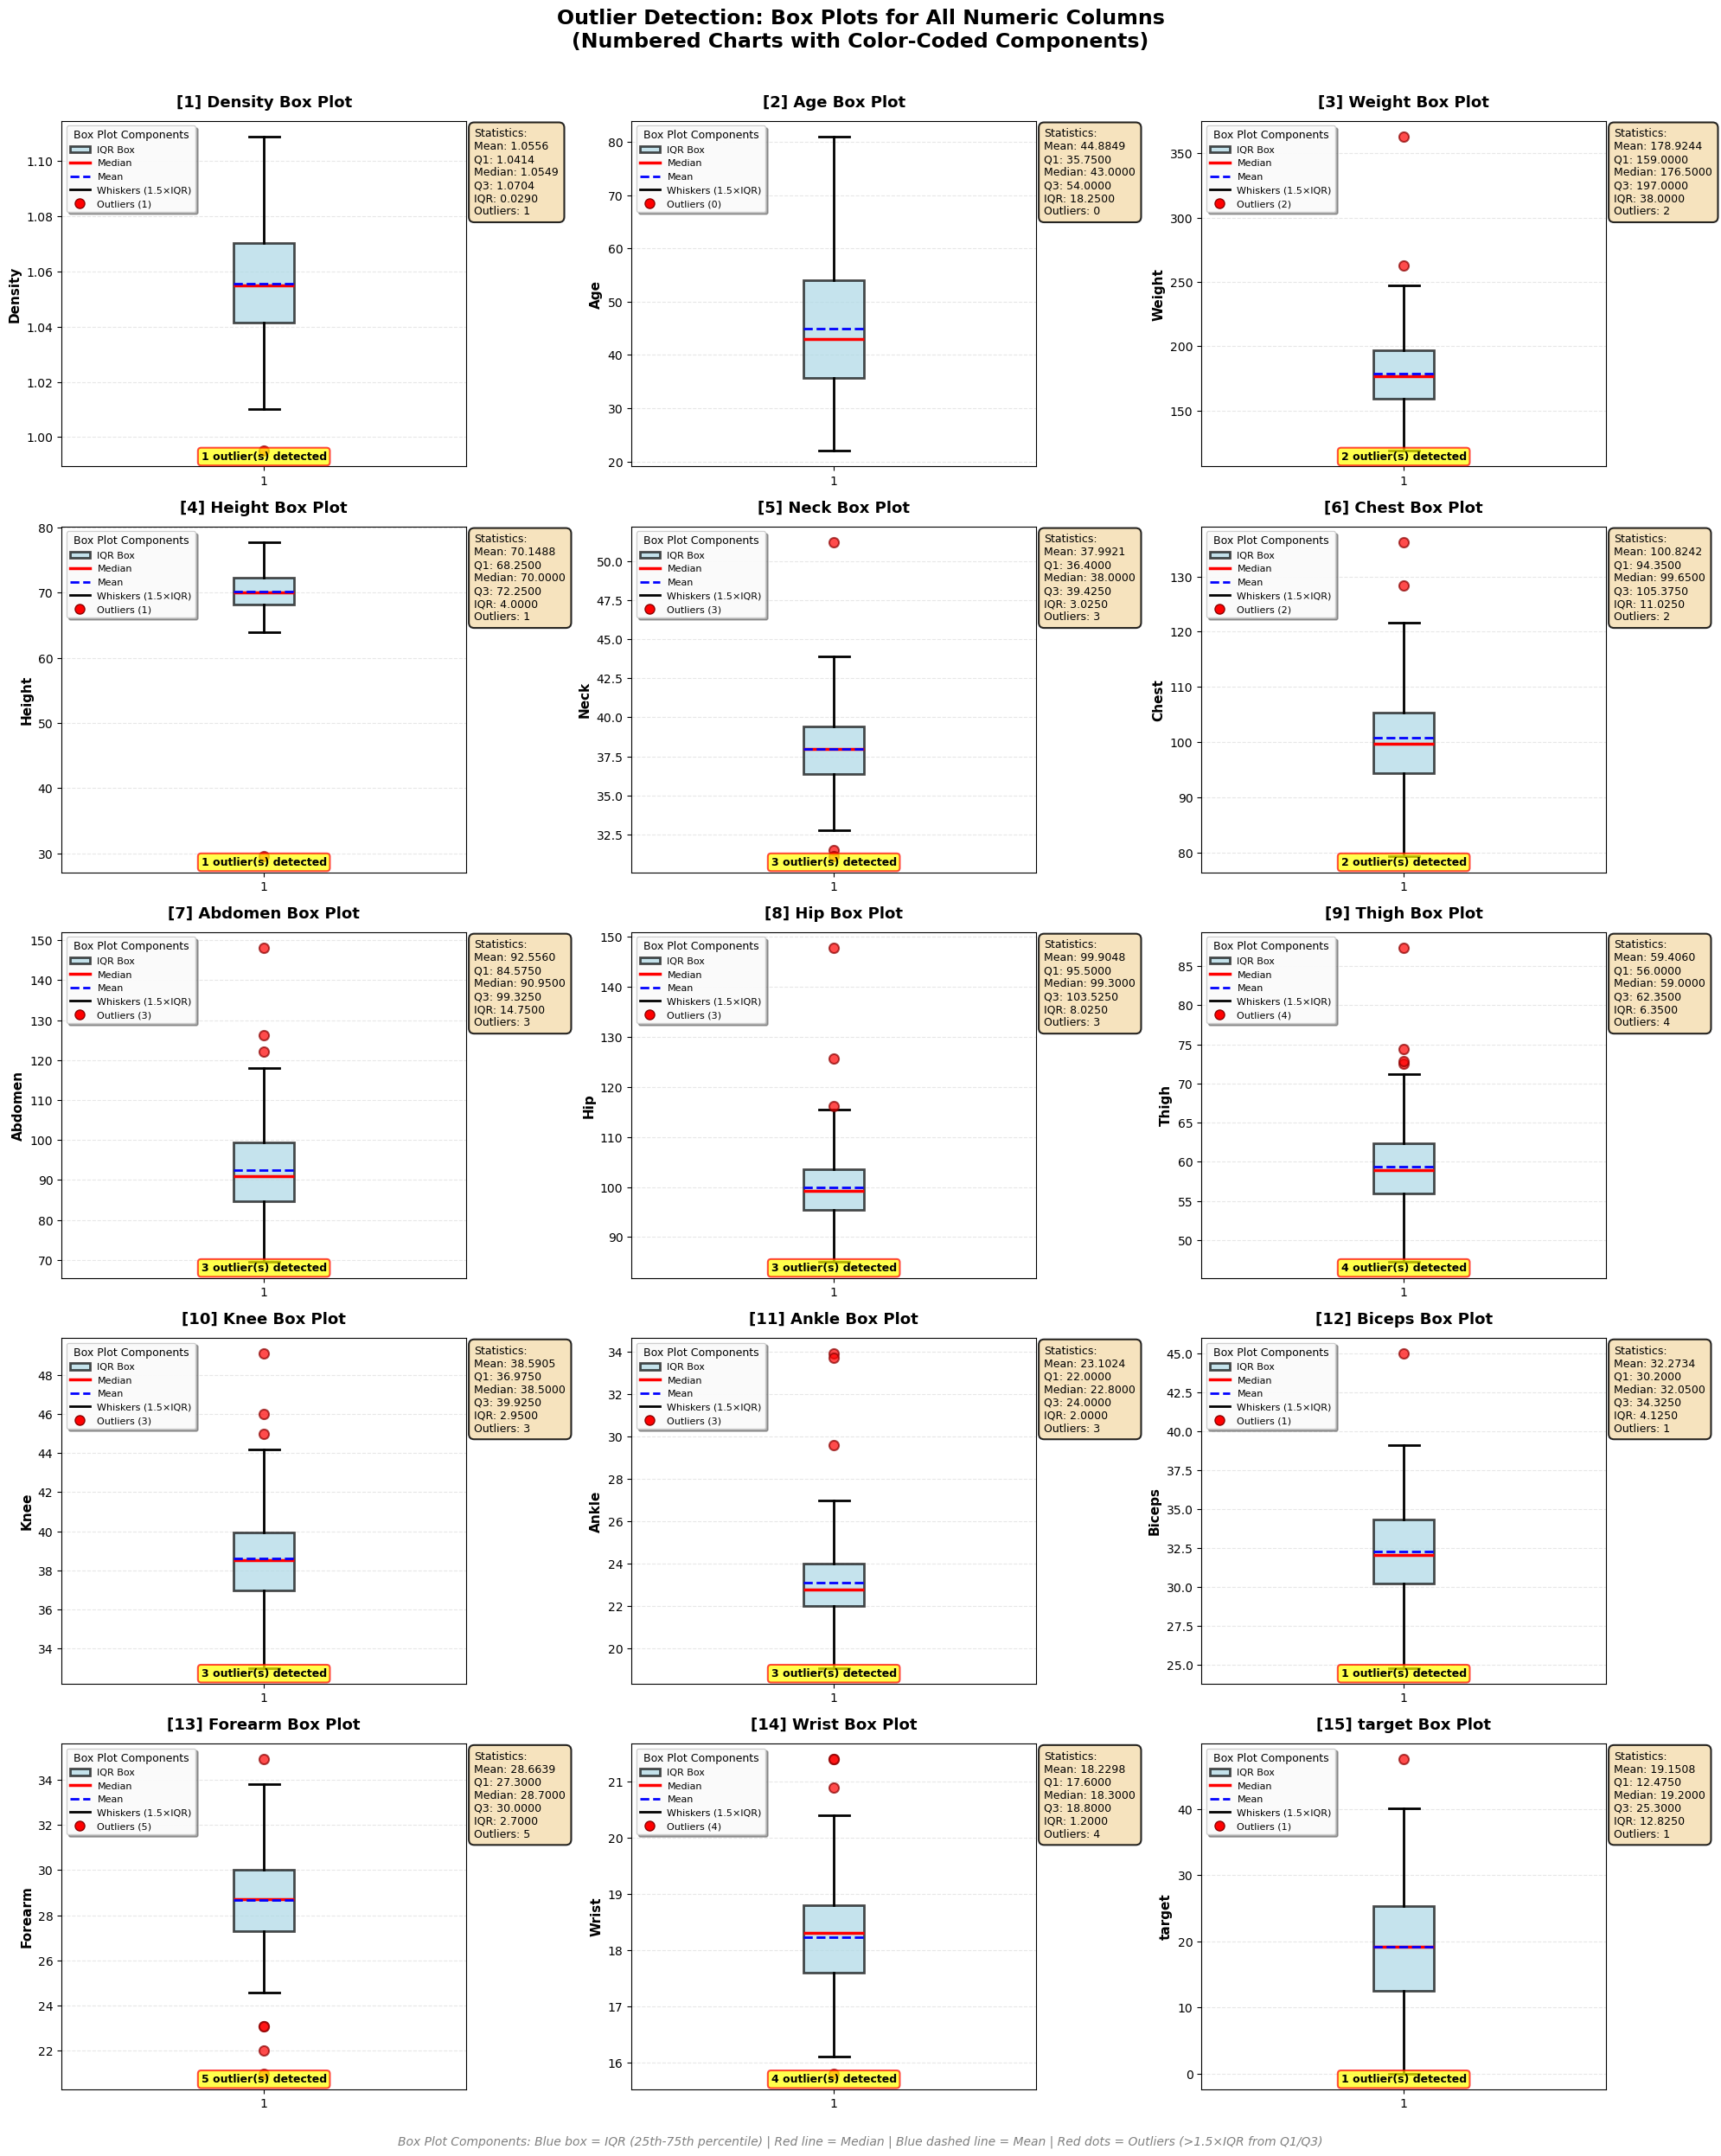


--------------------------------------------------------------------------------
OUTLIER SUMMARY TABLE
--------------------------------------------------------------------------------


,Column,Q1,Median,Q3,IQR,Lower Fence,Upper Fence,Outlier Count,Outlier %
0,Density,1.0414,1.0549,1.0704,0.0290,0.9979,1.1139,1,0.40%
1,Age,35.7500,43.0000,54.0000,18.2500,8.3750,81.3750,0,0.00%
2,Weight,159.0000,176.5000,197.0000,38.0000,102.0000,254.0000,2,0.79%
3,Height,68.2500,70.0000,72.2500,4.0000,62.2500,78.2500,1,0.40%
4,Neck,36.4000,38.0000,39.4250,3.0250,31.8625,43.9625,3,1.19%
5,Chest,94.3500,99.6500,105.3750,11.0250,77.8125,121.9125,2,0.79%
6,Abdomen,84.5750,90.9500,99.3250,14.7500,62.4500,121.4500,3,1.19%
7,Hip,95.5000,99.3000,103.5250,8.0250,83.4625,115.5625,3,1.19%
8,Thigh,56.0000,59.0000,62.3500,6.3500,46.4750,71.8750,4,1.59%
9,Knee,36.9750,38.5000,39.9250,2.9500,32.5500,44.3500,3,1.19%


In [69]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D  # Correct import location

# ============================================================================
# 2. BOX PLOTS - To identify outliers
# ============================================================================
print("\n" + "=" * 80)
print("OUTLIER DETECTION - Box Plots")
print("=" * 80)

from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D  # Correct import location

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    
    # Calculate statistics for annotations
    q1 = data.quantile(0.25)
    q2 = data.quantile(0.50)  # median
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    mean_val = data.mean()
    
    # Identify outliers
    outliers = data[(data < lower_fence) | (data > upper_fence)]
    outliers_count = len(outliers)
    
    # Create box plot with enhanced styling
    bp = axes[i].boxplot(data, vert=True, patch_artist=True,
                         showmeans=True, meanline=True,
                         boxprops=dict(linewidth=2, color='black'),
                         whiskerprops=dict(linewidth=2, color='black'),
                         capprops=dict(linewidth=2, color='black'),
                         medianprops=dict(linewidth=2.5, color='red'),
                         meanprops=dict(linewidth=2, color='blue', linestyle='--'),
                         flierprops=dict(marker='o', markerfacecolor='red', 
                                        markeredgecolor='darkred', markersize=8,
                                        alpha=0.7, markeredgewidth=1.5))
    
    # Color the box
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    
    # Color the median line
    for median in bp['medians']:
        median.set_color('red')
        median.set_linewidth(2.5)
    
    # Color the mean line
    for mean in bp['means']:
        mean.set_color('blue')
        mean.set_linestyle('--')
        mean.set_linewidth(2)
    
    # Enhance outlier visualization
    for flier in bp['fliers']:
        flier.set_marker('o')
        flier.set_markerfacecolor('red')
        flier.set_markeredgecolor('darkred')
        flier.set_markersize(8)
        flier.set_alpha(0.7)
        flier.set_markeredgewidth(1.5)
    
    # Set title with number badge
    title_text = f'[{i+1}] {col} Box Plot'
    axes[i].set_title(title_text, fontsize=13, fontweight='bold', pad=12)
    axes[i].set_ylabel(col, fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3, axis='y', linestyle='--')
    
    # Add statistics box (top right)
    stats_text = (f'Statistics:\n'
                  f'Mean: {mean_val:.4f}\n'
                  f'Q1: {q1:.4f}\n'
                  f'Median: {q2:.4f}\n'
                  f'Q3: {q3:.4f}\n'
                  f'IQR: {iqr:.4f}\n'
                  f'Outliers: {outliers_count}')
    
    axes[i].text(1.02, 0.98, stats_text, transform=axes[i].transAxes,
                fontsize=9, verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85, 
                         edgecolor='black', linewidth=1.5, pad=0.5))
    
    # Create legend elements
    legend_elements = [
        Rectangle((0,0),1,1, facecolor='lightblue', alpha=0.7, edgecolor='black', linewidth=2, label='IQR Box'),
        Line2D([0], [0], color='red', linewidth=2.5, label='Median'),
        Line2D([0], [0], color='blue', linestyle='--', linewidth=2, label='Mean'),
        Line2D([0], [0], color='black', linewidth=2, label='Whiskers (1.5×IQR)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
               markeredgecolor='darkred', markersize=8, linestyle='None', label=f'Outliers ({outliers_count})')
    ]
    
    axes[i].legend(handles=legend_elements, loc='upper left', fontsize=8, 
                  framealpha=0.95, fancybox=True, shadow=True, title='Box Plot Components',
                  title_fontsize=9)
    
    # Add annotation for outlier count if significant
    if outliers_count > 0:
        axes[i].text(0.5, 0.02, f'{outliers_count} outlier(s) detected', 
                    transform=axes[i].transAxes,
                    fontsize=9, ha='center', fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7,
                             edgecolor='red', linewidth=1.5))

# Hide extra subplots
for i in range(len(numeric_cols), len(axes)):
    axes[i].axis('off')

# Add overall title
plt.suptitle('Outlier Detection: Box Plots for All Numeric Columns\n(Numbered Charts with Color-Coded Components)', 
             fontsize=17, fontweight='bold', y=0.998)

# Add footer with explanation
fig.text(0.5, 0.01, 
         'Box Plot Components: Blue box = IQR (25th-75th percentile) | Red line = Median | Blue dashed line = Mean | Red dots = Outliers (>1.5×IQR from Q1/Q3)',
         ha='center', fontsize=10, style='italic', color='gray')

plt.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.show()

# Print outlier summary table
print("\n" + "-" * 80)
print("OUTLIER SUMMARY TABLE")
print("-" * 80)
outlier_summary = []
for col in numeric_cols:
    data = df[col].dropna()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    outliers = data[(data < lower_fence) | (data > upper_fence)]
    
    outlier_summary.append({
        'Column': col,
        'Q1': q1,
        'Median': data.median(),
        'Q3': q3,
        'IQR': iqr,
        'Lower Fence': lower_fence,
        'Upper Fence': upper_fence,
        'Outlier Count': len(outliers),
        'Outlier %': (len(outliers) / len(data) * 100)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df.style.format({
    'Q1': '{:.4f}',
    'Median': '{:.4f}',
    'Q3': '{:.4f}',
    'IQR': '{:.4f}',
    'Lower Fence': '{:.4f}',
    'Upper Fence': '{:.4f}',
    'Outlier Count': '{:.0f}',
    'Outlier %': '{:.2f}%'
}).background_gradient(subset=['Outlier Count'], cmap='Reds', vmin=0))


FEATURE-TARGET RELATIONSHIPS


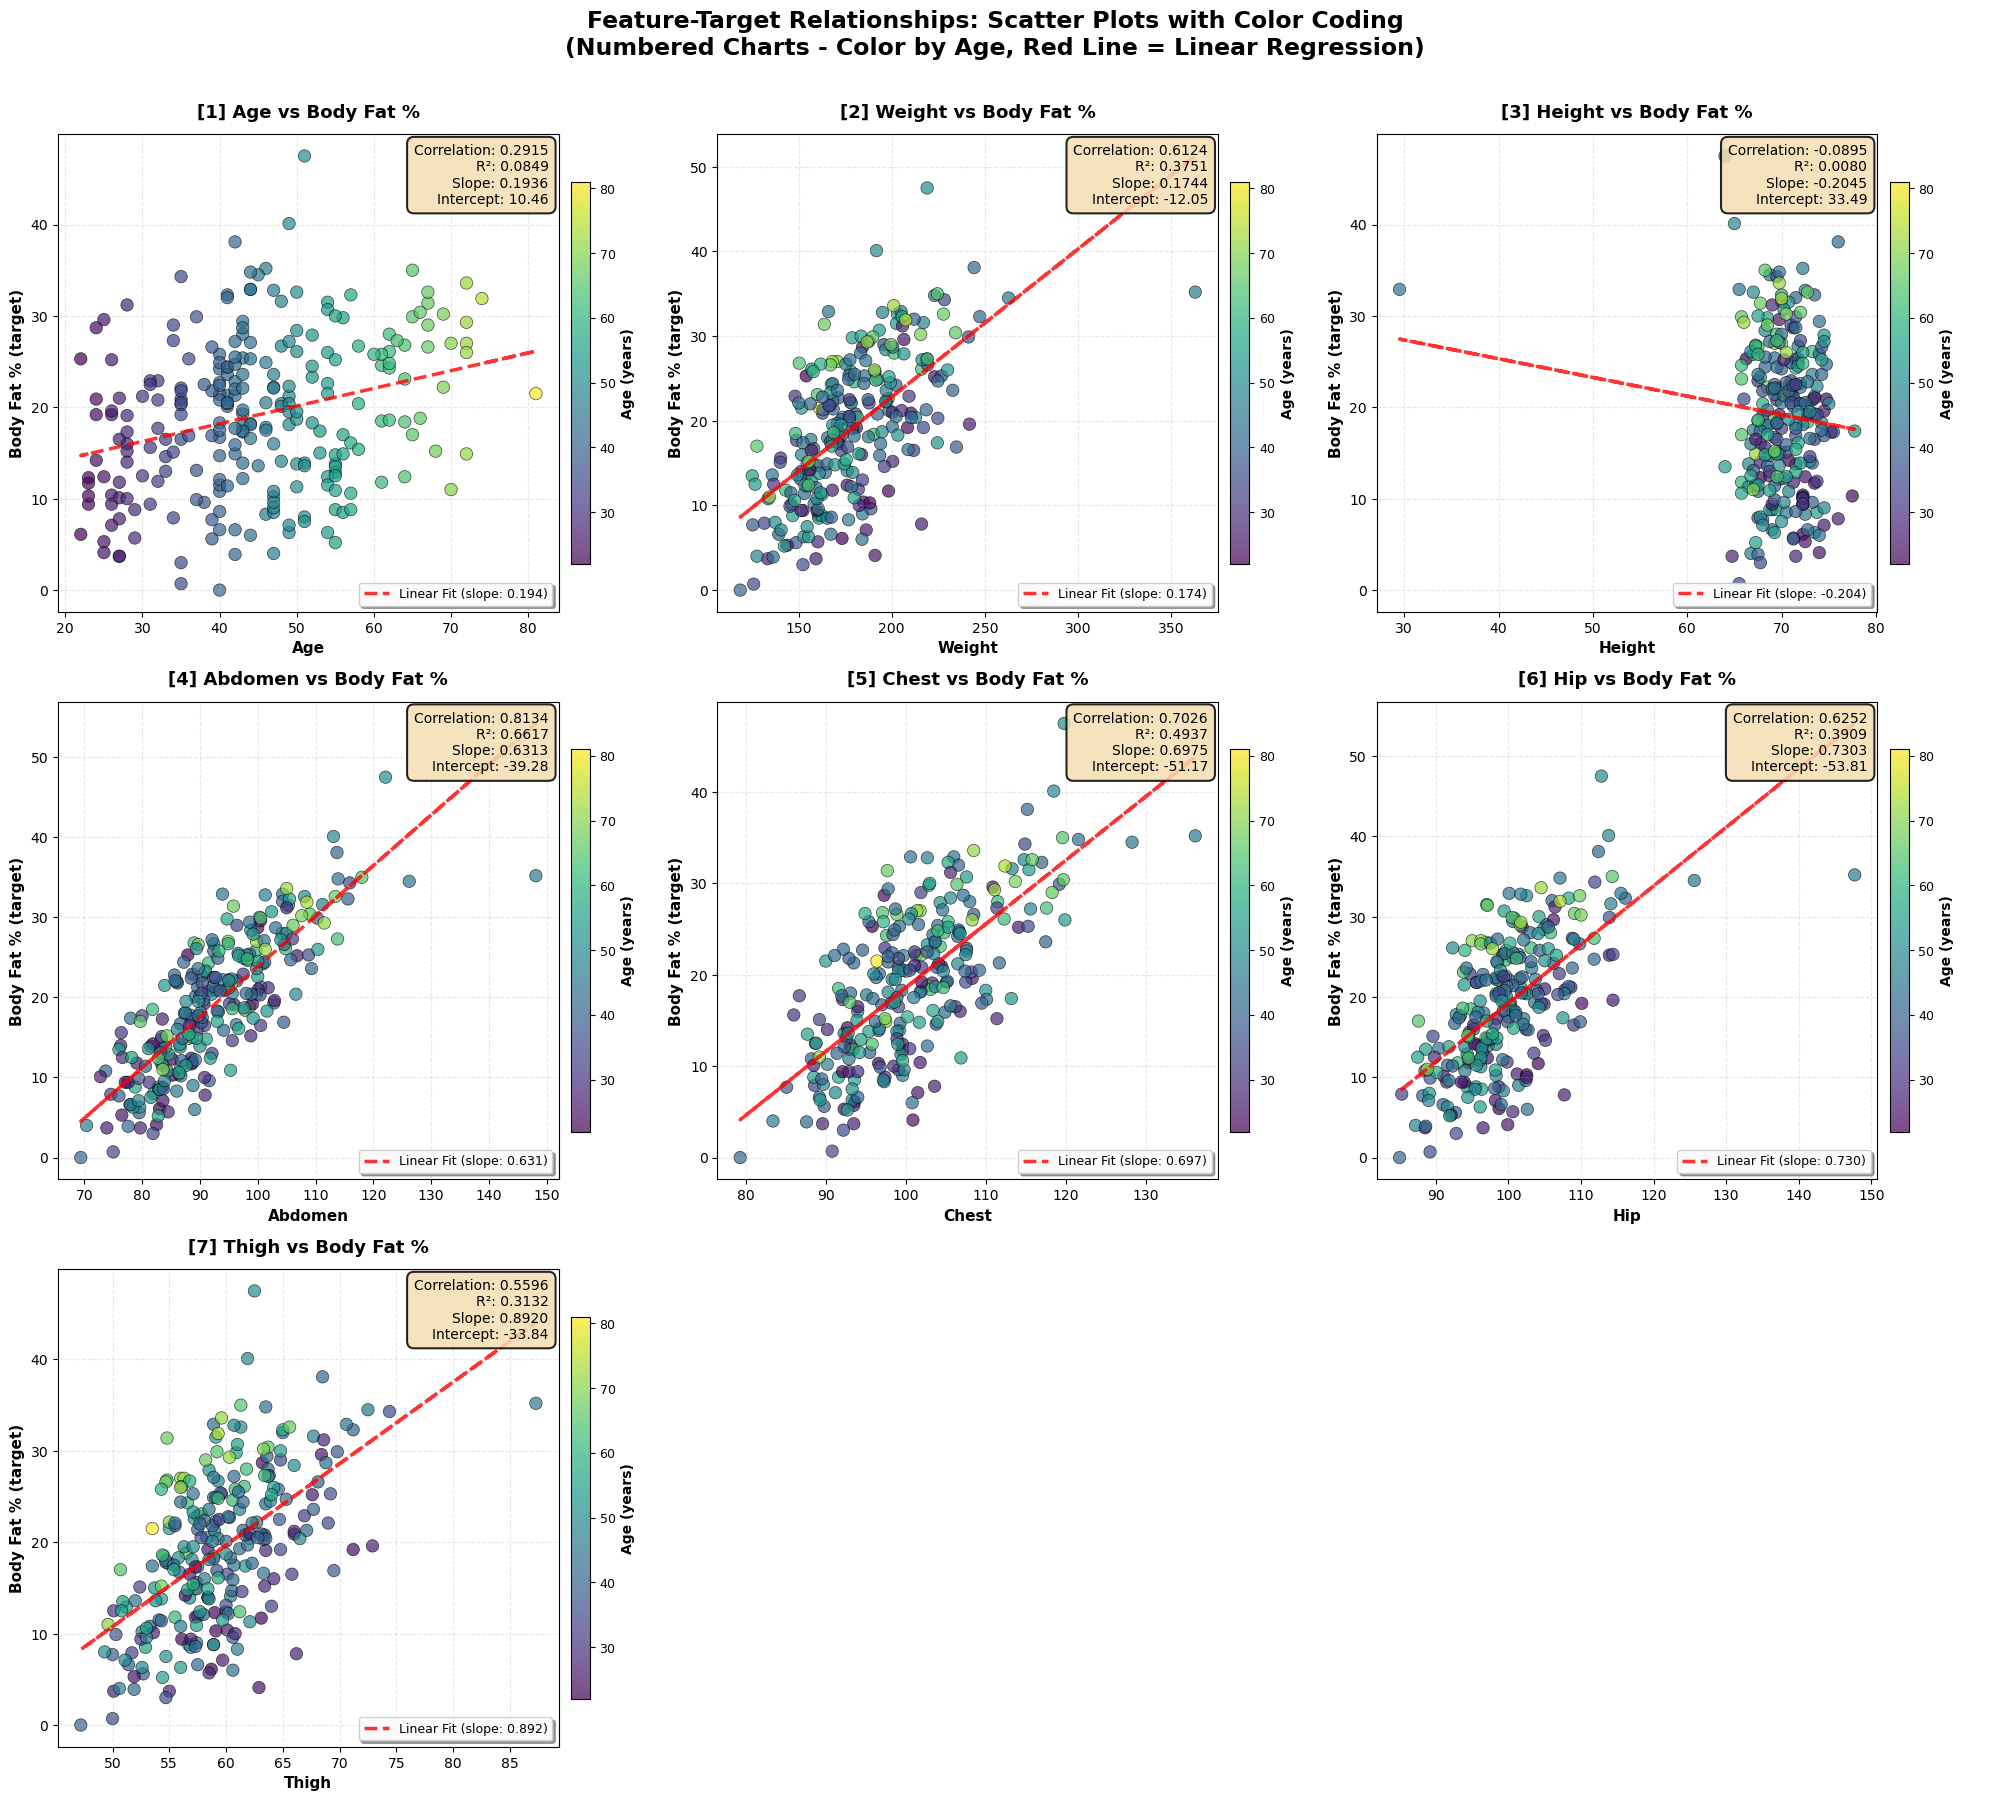

In [70]:
# ============================================================================
# 3. SCATTER PLOTS - Key features vs Target
# ============================================================================
print("\n" + "=" * 80)
print("FEATURE-TARGET RELATIONSHIPS")
print("=" * 80)

# Select key features (excluding target and density which is highly correlated with target)
key_features = ['Age', 'Weight', 'Height', 'Abdomen', 'Chest', 'Hip', 'Thigh']
n_feat = len(key_features)
n_cols_feat = 3
n_rows_feat = (n_feat + n_cols_feat - 1) // n_cols_feat

fig, axes = plt.subplots(n_rows_feat, n_cols_feat, figsize=(20, 6*n_rows_feat))
axes = axes.flatten() if n_rows_feat > 1 else [axes] if n_cols_feat == 1 else axes.flatten()

for i, feat in enumerate(key_features):
    # Calculate correlation
    corr = df[feat].corr(df['target'])
    
    # Color code by Age (or you can use target quartiles, or another variable)
    scatter = axes[i].scatter(df[feat], df['target'], 
                             c=df['Age'], cmap='viridis', 
                             alpha=0.7, s=80, edgecolors='black', linewidth=0.5)
    
    # Add regression line
    z = np.polyfit(df[feat], df['target'], 1)
    p = np.poly1d(z)
    axes[i].plot(df[feat], p(df[feat]), "r--", alpha=0.8, linewidth=2.5, 
                label=f'Linear Fit (slope: {z[0]:.3f})')
    
    # Set title with number badge
    title_text = f'[{i+1}] {feat} vs Body Fat %'
    axes[i].set_title(title_text, fontsize=13, fontweight='bold', pad=12)
    axes[i].set_xlabel(feat, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Body Fat % (target)', fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3, linestyle='--')
    
    # Add correlation and statistics box (top right)
    stats_text = (f'Correlation: {corr:.4f}\n'
                  f'R²: {corr**2:.4f}\n'
                  f'Slope: {z[0]:.4f}\n'
                  f'Intercept: {z[1]:.2f}')
    
    axes[i].text(0.98, 0.98, stats_text, transform=axes[i].transAxes,
                fontsize=10, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85, 
                         edgecolor='black', linewidth=1.5, pad=0.5))
    
    # Add legend for regression line
    axes[i].legend(loc='lower right', fontsize=9, framealpha=0.95, 
                  fancybox=True, shadow=True)
    
    # Add colorbar for age
    cbar = plt.colorbar(scatter, ax=axes[i], shrink=0.8, pad=0.02)
    cbar.set_label('Age (years)', fontsize=10, fontweight='bold')
    cbar.ax.tick_params(labelsize=9)

for i in range(n_feat, len(axes)):
    axes[i].axis('off')

# Add overall title
plt.suptitle('Feature-Target Relationships: Scatter Plots with Color Coding\n(Numbered Charts - Color by Age, Red Line = Linear Regression)', 
             fontsize=17, fontweight='bold', y=0.998)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()


FEATURE-TARGET RELATIONSHIPS


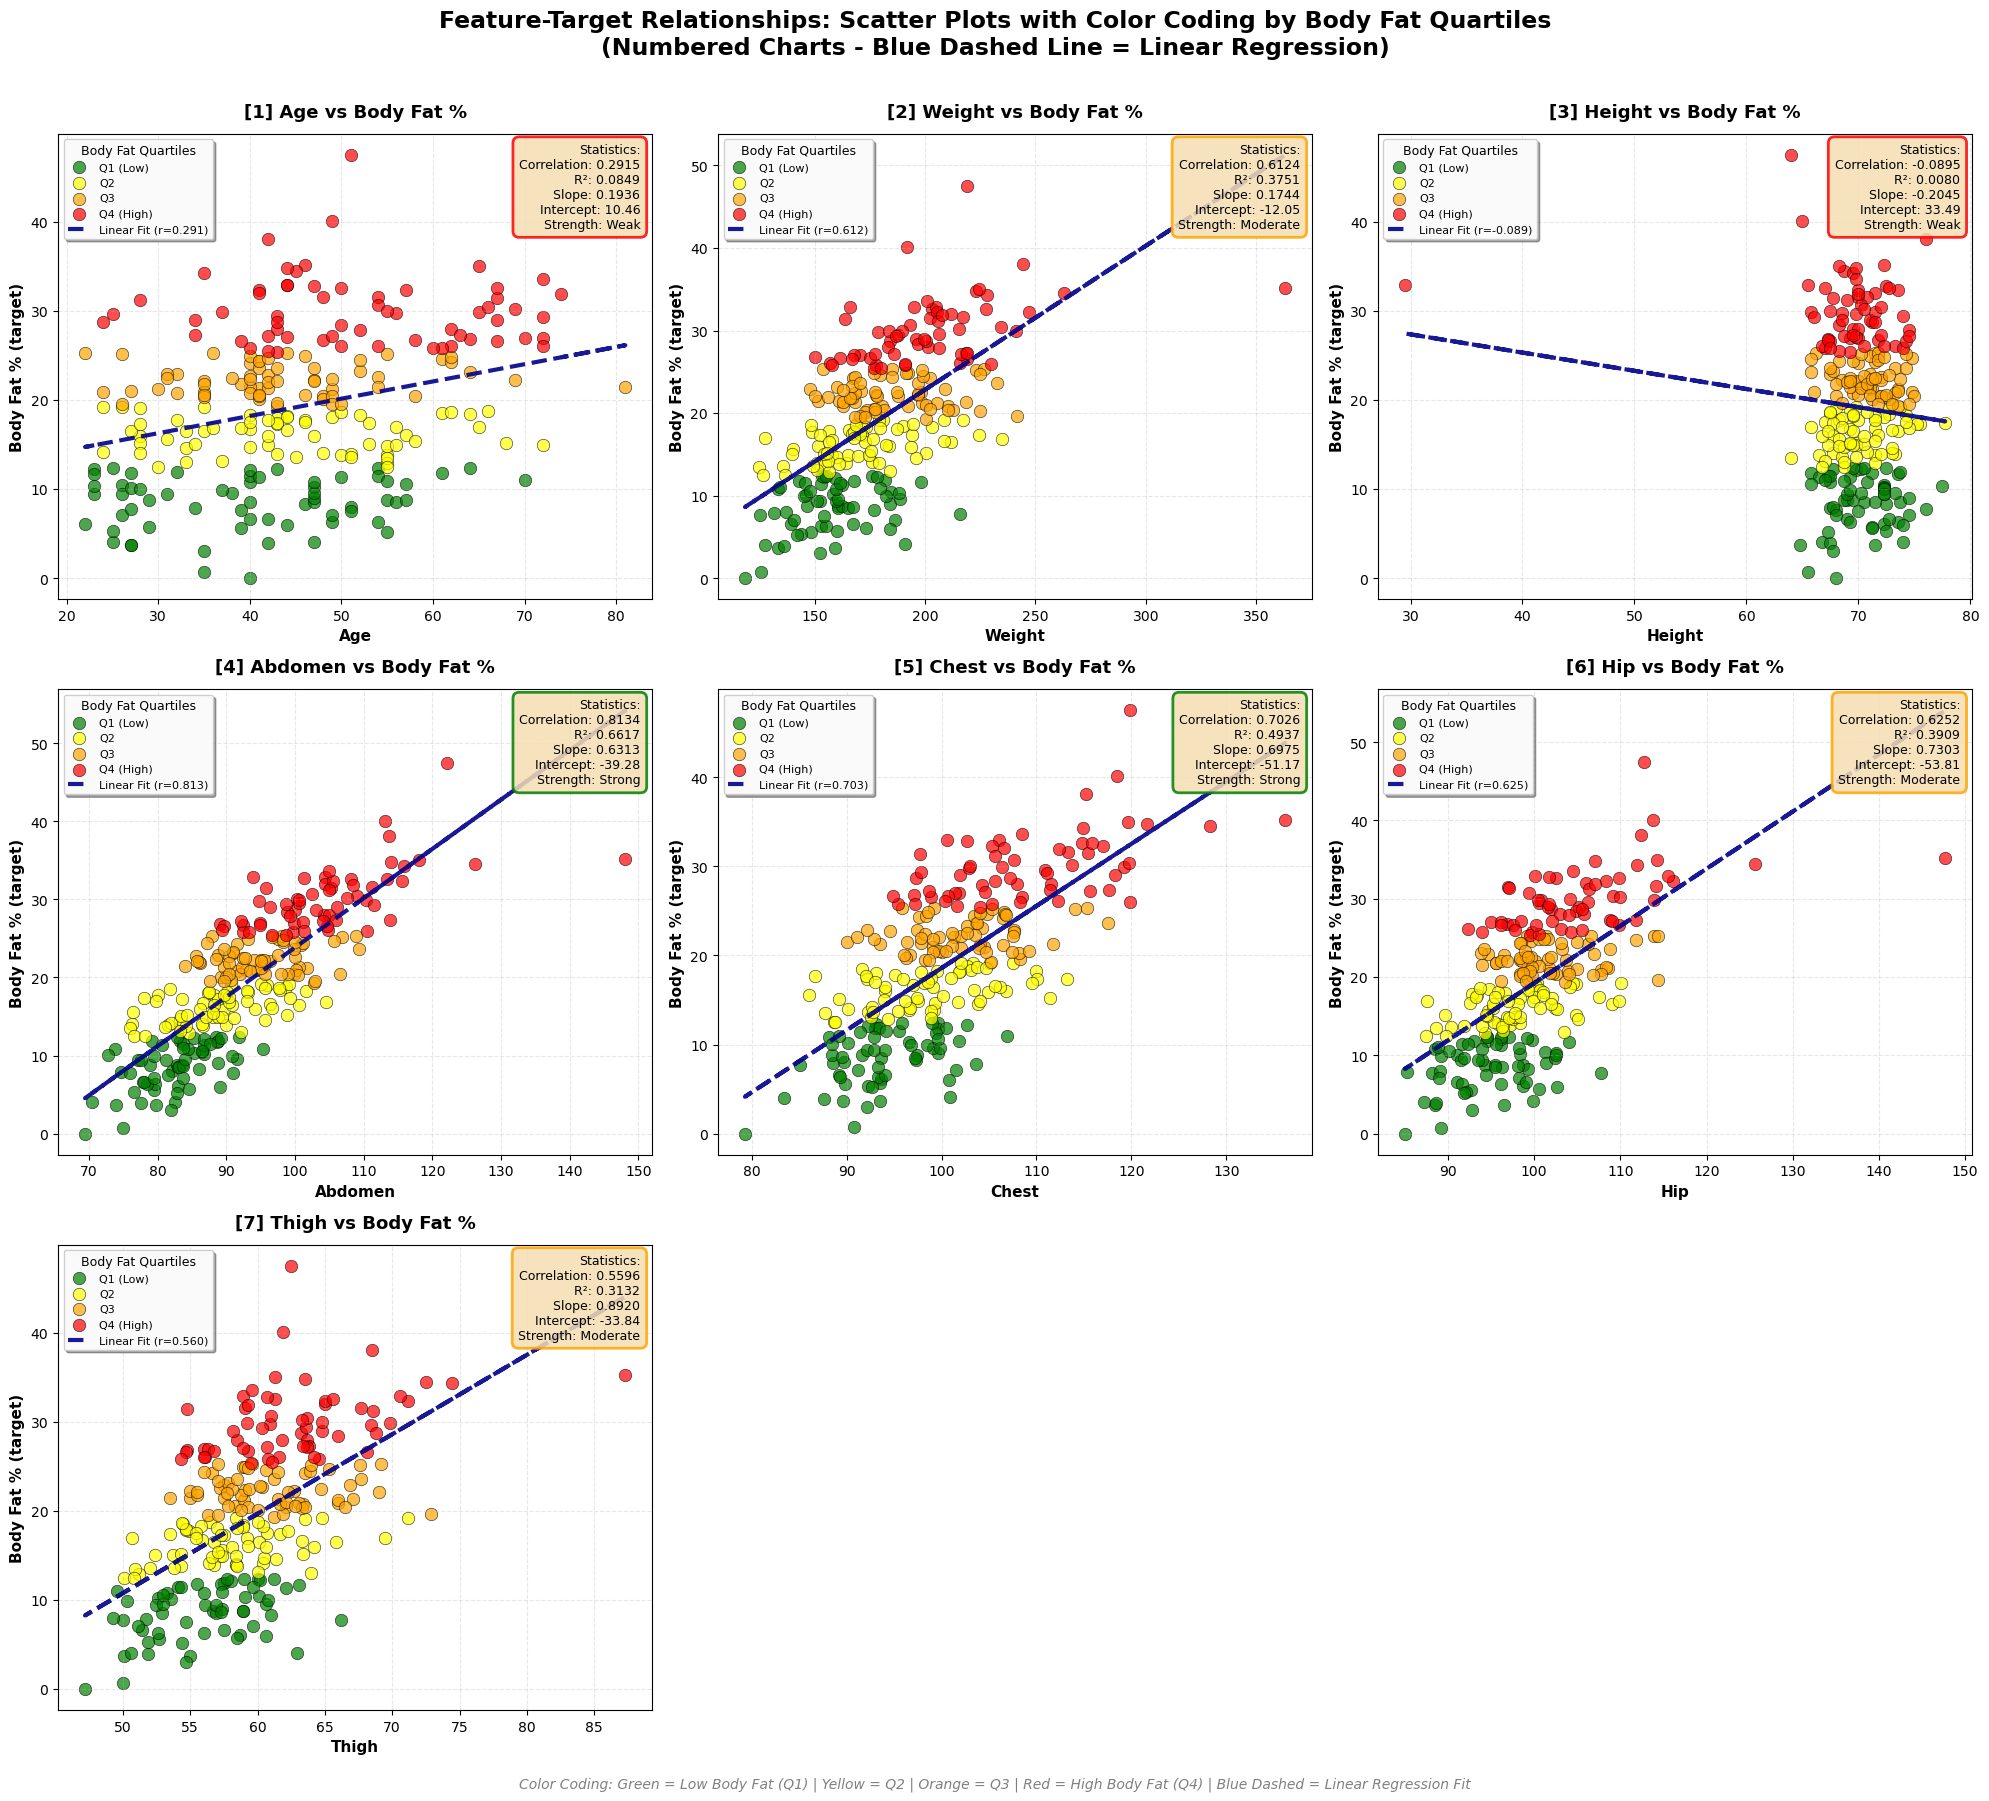


--------------------------------------------------------------------------------
CORRELATION SUMMARY TABLE
--------------------------------------------------------------------------------


,Feature,Correlation,|Correlation|,R²,Slope,Strength
3,Abdomen,0.8134,0.8134,0.6617,0.6313,Strong
4,Chest,0.7026,0.7026,0.4937,0.6975,Strong
5,Hip,0.6252,0.6252,0.3909,0.7303,Moderate
1,Weight,0.6124,0.6124,0.3751,0.1744,Moderate
6,Thigh,0.5596,0.5596,0.3132,0.8920,Moderate
0,Age,0.2915,0.2915,0.0849,0.1936,Weak
2,Height,-0.0895,0.0895,0.0080,-0.2045,Weak


In [71]:
# ============================================================================
# 3. SCATTER PLOTS - Key features vs Target (Enhanced with Multiple Color Schemes)
# ============================================================================
print("\n" + "=" * 80)
print("FEATURE-TARGET RELATIONSHIPS")
print("=" * 80)

# Select key features
key_features = ['Age', 'Weight', 'Height', 'Abdomen', 'Chest', 'Hip', 'Thigh']
n_feat = len(key_features)
n_cols_feat = 3
n_rows_feat = (n_feat + n_cols_feat - 1) // n_cols_feat

# Create target quartiles for color coding
df['target_quartile'] = pd.qcut(df['target'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
quartile_colors = {'Q1 (Low)': 'green', 'Q2': 'yellow', 'Q3': 'orange', 'Q4 (High)': 'red'}

fig, axes = plt.subplots(n_rows_feat, n_cols_feat, figsize=(20, 6*n_rows_feat))
axes = axes.flatten() if n_rows_feat > 1 else [axes] if n_cols_feat == 1 else axes.flatten()

for i, feat in enumerate(key_features):
    # Calculate correlation and regression
    corr = df[feat].corr(df['target'])
    z = np.polyfit(df[feat], df['target'], 1)
    p = np.poly1d(z)
    
    # Color code by target quartiles
    for quartile, color in quartile_colors.items():
        mask = df['target_quartile'] == quartile
        axes[i].scatter(df.loc[mask, feat], df.loc[mask, 'target'], 
                       c=color, label=quartile, alpha=0.7, s=80, 
                       edgecolors='black', linewidth=0.5)
    
    # Add regression line
    axes[i].plot(df[feat], p(df[feat]), "darkblue", linestyle='--', 
                linewidth=3, alpha=0.9, label=f'Linear Fit (r={corr:.3f})')
    
    # Add perfect correlation reference line (optional)
    # axes[i].plot([df[feat].min(), df[feat].max()], 
    #             [df['target'].min(), df['target'].max()], 
    #             'gray', linestyle=':', linewidth=1, alpha=0.5)
    
    # Set title with number badge
    title_text = f'[{i+1}] {feat} vs Body Fat %'
    axes[i].set_title(title_text, fontsize=13, fontweight='bold', pad=12)
    axes[i].set_xlabel(feat, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Body Fat % (target)', fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3, linestyle='--')
    
    # Add statistics box (top right)
    stats_text = (f'Statistics:\n'
                  f'Correlation: {corr:.4f}\n'
                  f'R²: {corr**2:.4f}\n'
                  f'Slope: {z[0]:.4f}\n'
                  f'Intercept: {z[1]:.2f}\n'
                  f'Strength: {"Strong" if abs(corr) > 0.7 else "Moderate" if abs(corr) > 0.4 else "Weak"}')
    
    # Color code the strength indicator
    strength_color = 'green' if abs(corr) > 0.7 else 'orange' if abs(corr) > 0.4 else 'red'
    
    axes[i].text(0.98, 0.98, stats_text, transform=axes[i].transAxes,
                fontsize=9, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85, 
                         edgecolor=strength_color, linewidth=2, pad=0.5))
    
    # Add legend (left side)
    axes[i].legend(loc='upper left', fontsize=8, framealpha=0.95, 
                  fancybox=True, shadow=True, title='Body Fat Quartiles',
                  title_fontsize=9, ncol=1)

for i in range(n_feat, len(axes)):
    axes[i].axis('off')

# Add overall title
plt.suptitle('Feature-Target Relationships: Scatter Plots with Color Coding by Body Fat Quartiles\n(Numbered Charts - Blue Dashed Line = Linear Regression)', 
             fontsize=17, fontweight='bold', y=0.998)

# Add footer explanation
fig.text(0.5, 0.01, 
         'Color Coding: Green = Low Body Fat (Q1) | Yellow = Q2 | Orange = Q3 | Red = High Body Fat (Q4) | Blue Dashed = Linear Regression Fit',
         ha='center', fontsize=10, style='italic', color='gray')

plt.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.show()

# Print correlation summary table
print("\n" + "-" * 80)
print("CORRELATION SUMMARY TABLE")
print("-" * 80)
corr_summary = []
for feat in key_features:
    corr = df[feat].corr(df['target'])
    z = np.polyfit(df[feat], df['target'], 1)
    corr_summary.append({
        'Feature': feat,
        'Correlation': corr,
        '|Correlation|': abs(corr),
        'R²': corr**2,
        'Slope': z[0],
        'Strength': 'Strong' if abs(corr) > 0.7 else 'Moderate' if abs(corr) > 0.4 else 'Weak'
    })

corr_df = pd.DataFrame(corr_summary).sort_values('|Correlation|', ascending=False)
display(corr_df.style.format({
    'Correlation': '{:.4f}',
    '|Correlation|': '{:.4f}',
    'R²': '{:.4f}',
    'Slope': '{:.4f}'
}).background_gradient(subset=['Correlation', '|Correlation|'], cmap='RdYlGn_r', vmin=-1, vmax=1))


FEATURE-TARGET RELATIONSHIPS


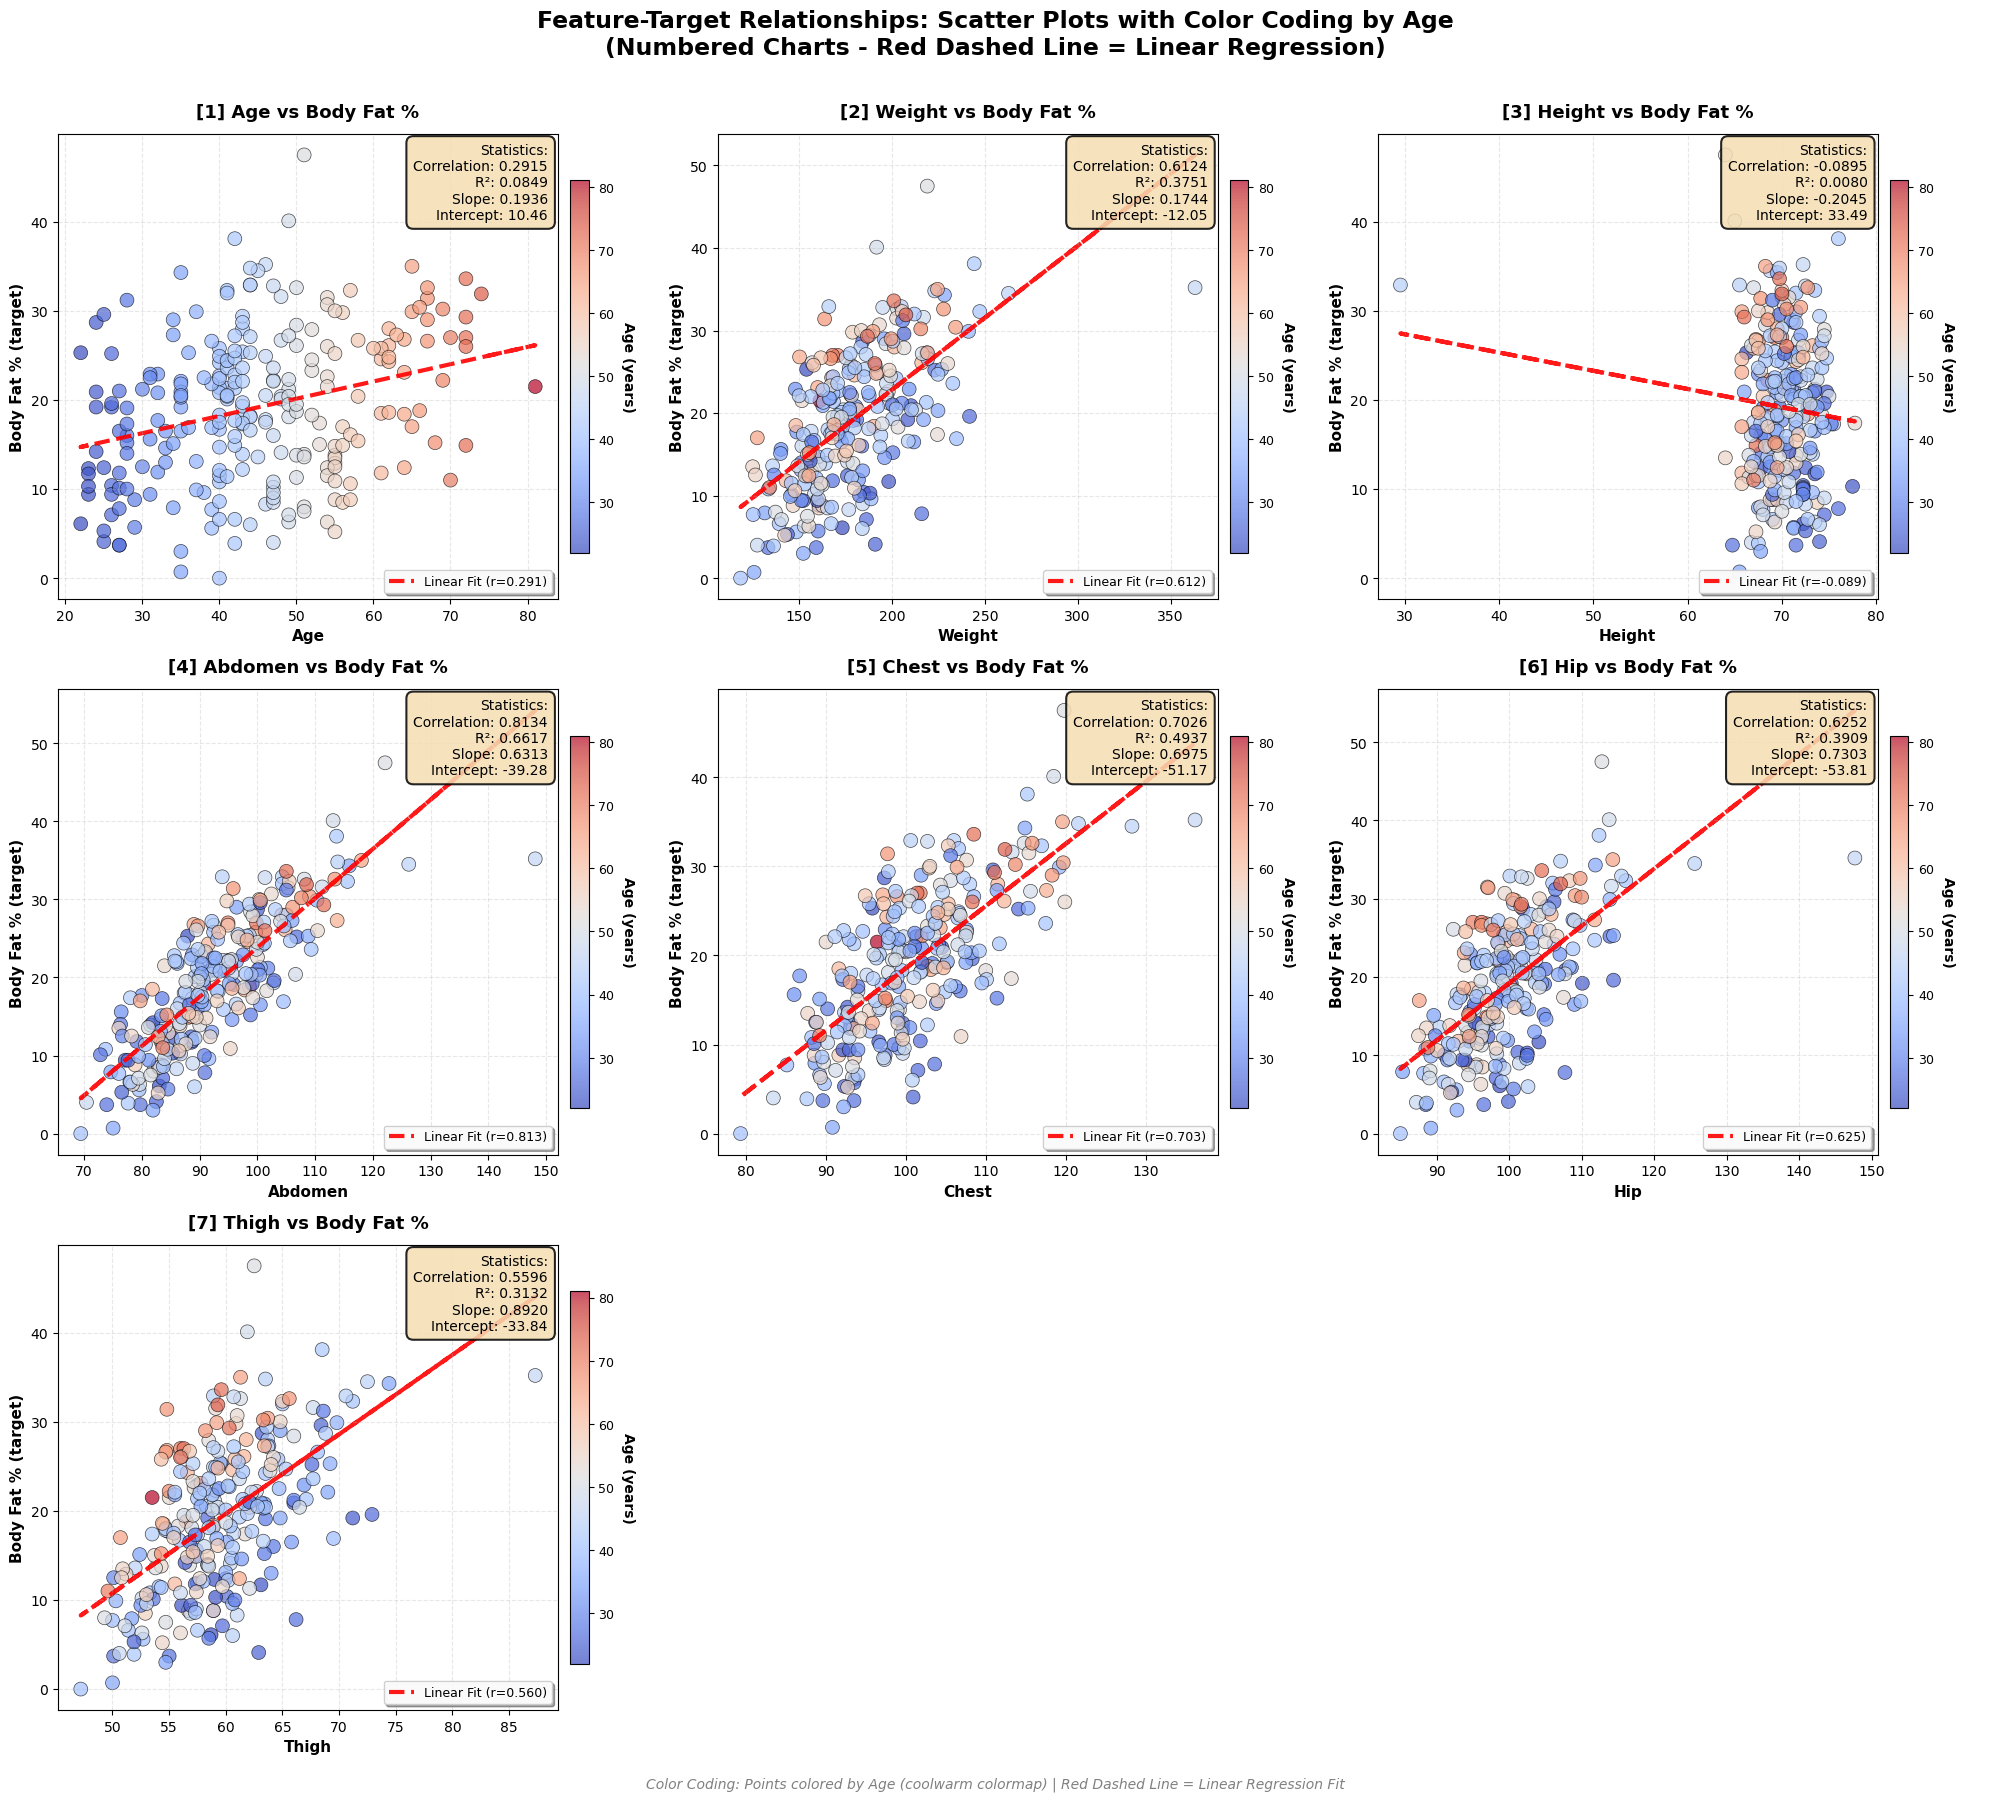


--------------------------------------------------------------------------------
CORRELATION SUMMARY TABLE
--------------------------------------------------------------------------------


,Feature,Correlation,|Correlation|,R²,Slope
3,Abdomen,0.8134,0.8134,0.6617,0.6313
4,Chest,0.7026,0.7026,0.4937,0.6975
5,Hip,0.6252,0.6252,0.3909,0.7303
1,Weight,0.6124,0.6124,0.3751,0.1744
6,Thigh,0.5596,0.5596,0.3132,0.8920
0,Age,0.2915,0.2915,0.0849,0.1936
2,Height,-0.0895,0.0895,0.0080,-0.2045


In [72]:
# ============================================================================
# 3. SCATTER PLOTS - Key features vs Target (Color by Age)
# ============================================================================
print("\n" + "=" * 80)
print("FEATURE-TARGET RELATIONSHIPS")
print("=" * 80)

key_features = ['Age', 'Weight', 'Height', 'Abdomen', 'Chest', 'Hip', 'Thigh']
n_feat = len(key_features)
n_cols_feat = 3
n_rows_feat = (n_feat + n_cols_feat - 1) // n_cols_feat

fig, axes = plt.subplots(n_rows_feat, n_cols_feat, figsize=(20, 6*n_rows_feat))
axes = axes.flatten() if n_rows_feat > 1 else [axes] if n_cols_feat == 1 else axes.flatten()

for i, feat in enumerate(key_features):
    # Calculate correlation and regression
    corr = df[feat].corr(df['target'])
    z = np.polyfit(df[feat], df['target'], 1)
    p = np.poly1d(z)
    
    # Color code by Age with continuous colormap
    scatter = axes[i].scatter(df[feat], df['target'], 
                             c=df['Age'], cmap='coolwarm', 
                             alpha=0.7, s=100, edgecolors='black', linewidth=0.5,
                             vmin=df['Age'].min(), vmax=df['Age'].max())
    
    # Add regression line
    axes[i].plot(df[feat], p(df[feat]), "red", linestyle='--', 
                linewidth=3, alpha=0.9, label=f'Linear Fit (r={corr:.3f})', zorder=1)
    
    # Set title with number badge
    title_text = f'[{i+1}] {feat} vs Body Fat %'
    axes[i].set_title(title_text, fontsize=13, fontweight='bold', pad=12)
    axes[i].set_xlabel(feat, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Body Fat % (target)', fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3, linestyle='--', zorder=0)
    
    # Add statistics box (top right)
    stats_text = (f'Statistics:\n'
                  f'Correlation: {corr:.4f}\n'
                  f'R²: {corr**2:.4f}\n'
                  f'Slope: {z[0]:.4f}\n'
                  f'Intercept: {z[1]:.2f}')
    
    axes[i].text(0.98, 0.98, stats_text, transform=axes[i].transAxes,
                fontsize=10, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85, 
                         edgecolor='black', linewidth=1.5, pad=0.5), zorder=2)
    
    # Add legend for regression line (removed zorder parameter)
    axes[i].legend(loc='lower right', fontsize=9, framealpha=0.95, 
                  fancybox=True, shadow=True)
    
    # Add colorbar for age
    cbar = plt.colorbar(scatter, ax=axes[i], shrink=0.8, pad=0.02)
    cbar.set_label('Age (years)', fontsize=10, fontweight='bold', rotation=270, labelpad=15)
    cbar.ax.tick_params(labelsize=9)

for i in range(n_feat, len(axes)):
    axes[i].axis('off')

# Add overall title
plt.suptitle('Feature-Target Relationships: Scatter Plots with Color Coding by Age\n(Numbered Charts - Red Dashed Line = Linear Regression)', 
             fontsize=17, fontweight='bold', y=0.998)

# Add footer explanation
fig.text(0.5, 0.01, 
         'Color Coding: Points colored by Age (coolwarm colormap) | Red Dashed Line = Linear Regression Fit',
         ha='center', fontsize=10, style='italic', color='gray')

plt.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.show()

# Print correlation summary
print("\n" + "-" * 80)
print("CORRELATION SUMMARY TABLE")
print("-" * 80)
corr_summary = []
for feat in key_features:
    corr = df[feat].corr(df['target'])
    z = np.polyfit(df[feat], df['target'], 1)
    corr_summary.append({
        'Feature': feat,
        'Correlation': corr,
        '|Correlation|': abs(corr),
        'R²': corr**2,
        'Slope': z[0]
    })

corr_df = pd.DataFrame(corr_summary).sort_values('|Correlation|', ascending=False)
display(corr_df.style.format({
    'Correlation': '{:.4f}',
    '|Correlation|': '{:.4f}',
    'R²': '{:.4f}',
    'Slope': '{:.4f}'
}).background_gradient(subset=['Correlation'], cmap='RdYlGn_r', vmin=-1, vmax=1))


CORRELATION WITH TARGET


,Feature,Correlation,|Correlation|,R²,Strength,Direction
0,target,1.000000,1.000000,1.000000,Very Strong,Positive
1,Density,-0.987782,0.987782,0.975714,Very Strong,Negative
2,Abdomen,0.813432,0.813432,0.661672,Very Strong,Positive
3,Chest,0.702620,0.702620,0.493675,Strong,Positive
4,Hip,0.625201,0.625201,0.390876,Strong,Positive
5,Weight,0.612414,0.612414,0.375051,Strong,Positive
6,Thigh,0.559608,0.559608,0.313161,Moderate,Positive
7,Knee,0.508665,0.508665,0.258740,Moderate,Positive
8,Biceps,0.493271,0.493271,0.243316,Moderate,Positive
9,Neck,0.490592,0.490592,0.240680,Moderate,Positive


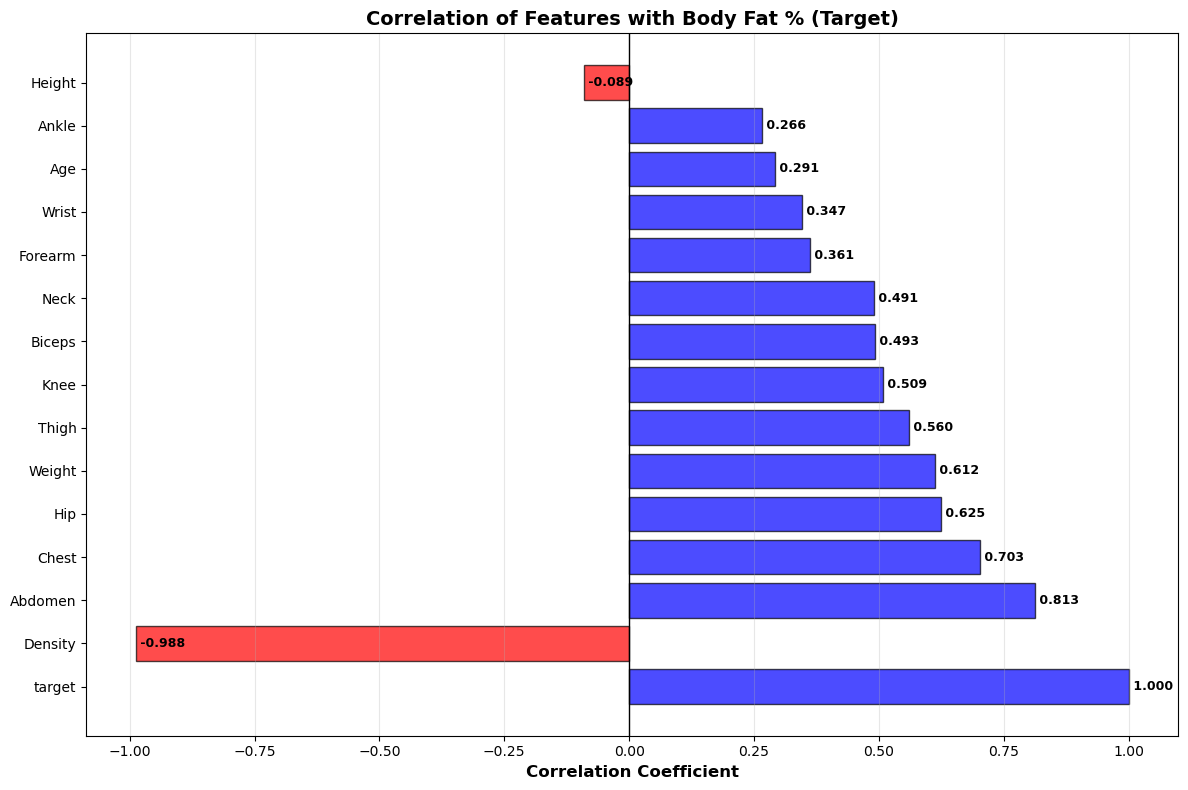

In [73]:
# ============================================================================
# 4. CORRELATION ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("CORRELATION WITH TARGET")
print("=" * 80)

# Calculate correlations with target
correlations = df.select_dtypes(include=[np.number]).corrwith(df['target']).sort_values(key=abs, ascending=False)

# Convert to DataFrame with additional information
corr_table = pd.DataFrame({
    'Feature': correlations.index,
    'Correlation': correlations.values,
    '|Correlation|': correlations.abs().values,
    'R²': correlations.values ** 2,
    'Strength': ['Very Strong' if abs(x) > 0.8 else 'Strong' if abs(x) > 0.6 else 'Moderate' if abs(x) > 0.4 else 'Weak' for x in correlations.values],
    'Direction': ['Positive' if x > 0 else 'Negative' for x in correlations.values]
})

# Display with enhanced styling
display(corr_table.style.format({
    'Correlation': '{:.6f}',
    '|Correlation|': '{:.6f}',
    'R²': '{:.6f}'
}).background_gradient(subset=['Correlation'], cmap='RdYlGn_r', vmin=-1, vmax=1)
  .background_gradient(subset=['|Correlation|'], cmap='YlOrRd', vmin=0, vmax=1)
  .set_caption('Correlation with Target (Sorted by Absolute Value)')
  .set_table_styles([
      {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), 
                                        ('text-align', 'center'), ('padding', '10px')]},
      {'selector': 'th', 'props': [('background-color', '#4472C4'), ('color', 'white'), 
                                  ('font-weight', 'bold'), ('text-align', 'center')]},
      {'selector': 'td', 'props': [('text-align', 'center')]}
  ]))

# Visualize correlations with target
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['red' if x < 0 else 'blue' for x in correlations.values]
bars = ax.barh(range(len(correlations)), correlations.values, color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(correlations)))
ax.set_yticklabels(correlations.index, fontsize=10)
ax.set_xlabel('Correlation Coefficient', fontsize=12, fontweight='bold')
ax.set_title('Correlation of Features with Body Fat % (Target)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (idx, val) in enumerate(correlations.items()):
    ax.text(val, i, f' {val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


FEATURE-FEATURE CORRELATION MATRIX


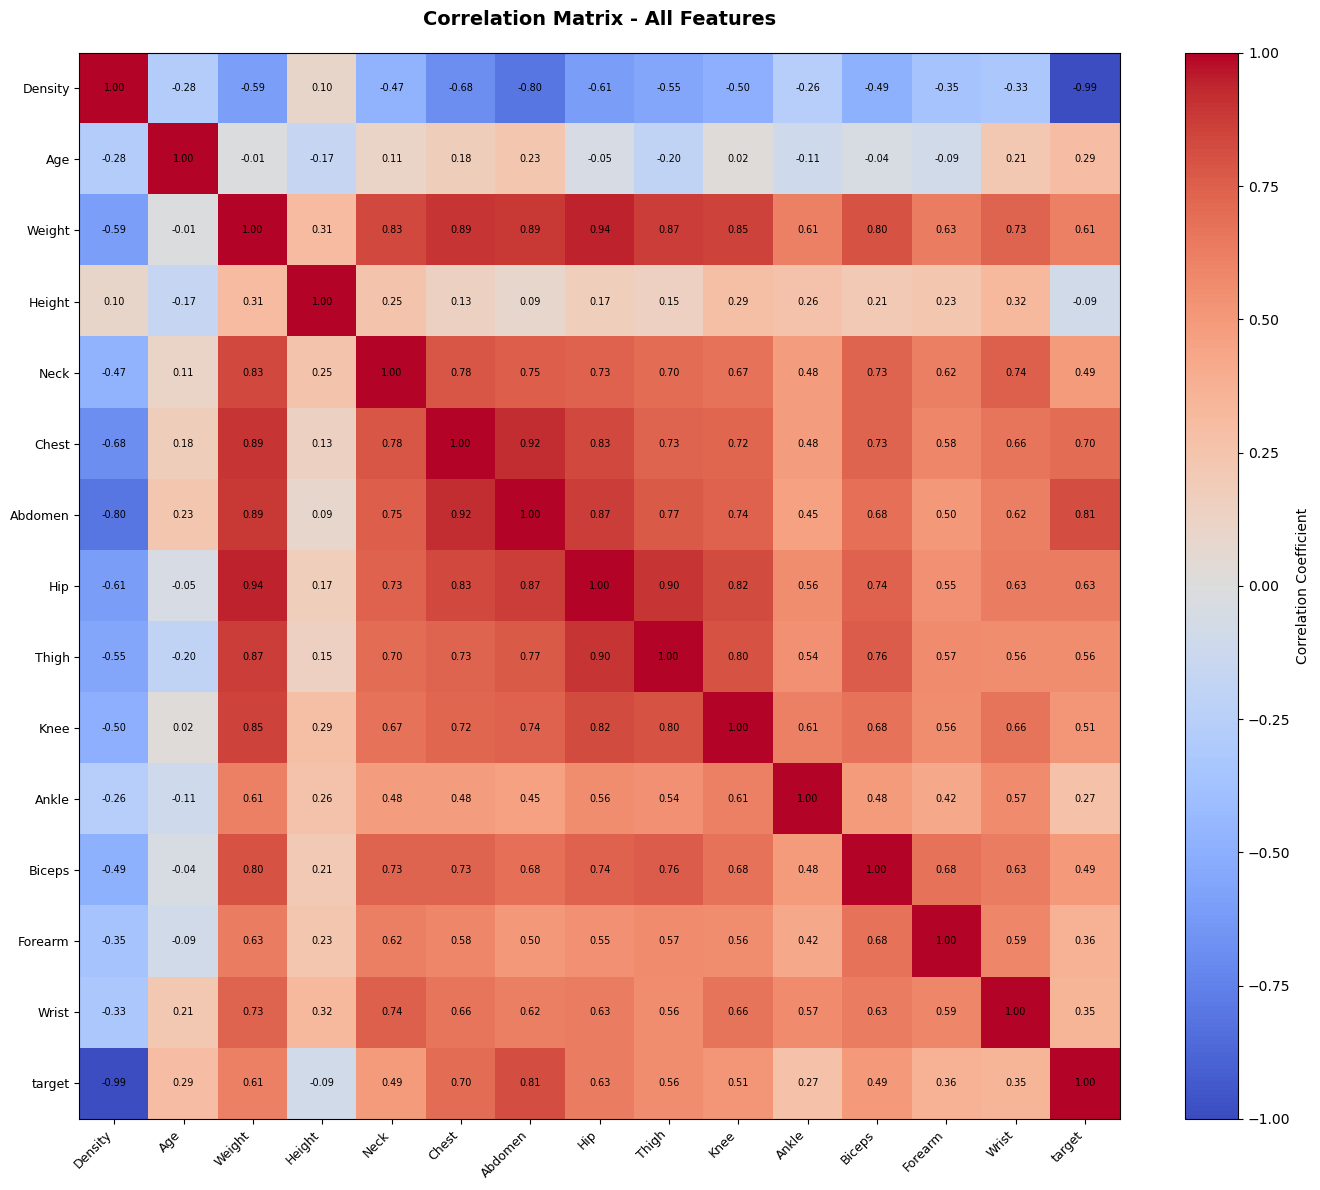

In [74]:
# ============================================================================
# 5. PAIRWISE CORRELATION HEATMAP (for feature relationships)
# ============================================================================
print("\n" + "=" * 80)
print("FEATURE-FEATURE CORRELATION MATRIX")
print("=" * 80)

corr_matrix = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr_matrix.columns, fontsize=9)
ax.set_title('Correlation Matrix - All Features', fontsize=14, fontweight='bold', pad=20)

# Add correlation values as text
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=7)

plt.colorbar(im, ax=ax, label='Correlation Coefficient')
plt.tight_layout()
plt.show()


TARGET DISTRIBUTION ANALYSIS

TARGET QUARTILE RANGES


,Quartile,Min Body Fat %,Max Body Fat %,Count
0,Q1 (Low),0.00,12.40,63
1,Q2,12.50,19.20,64
2,Q3,19.30,25.30,64
3,Q4 (High),25.40,47.50,61



MEAN VALUES OF KEY FEATURES BY TARGET QUARTILE


,Quartile,Age,Weight,Abdomen,Chest,Hip
0,Q1 (Low),40.16,158.55,82.48,94.13,94.87
1,Q2,44.38,170.54,88.83,98.59,97.91
2,Q3,43.42,185.58,94.96,102.03,101.62
3,Q4 (High),51.84,201.77,104.35,108.82,105.39


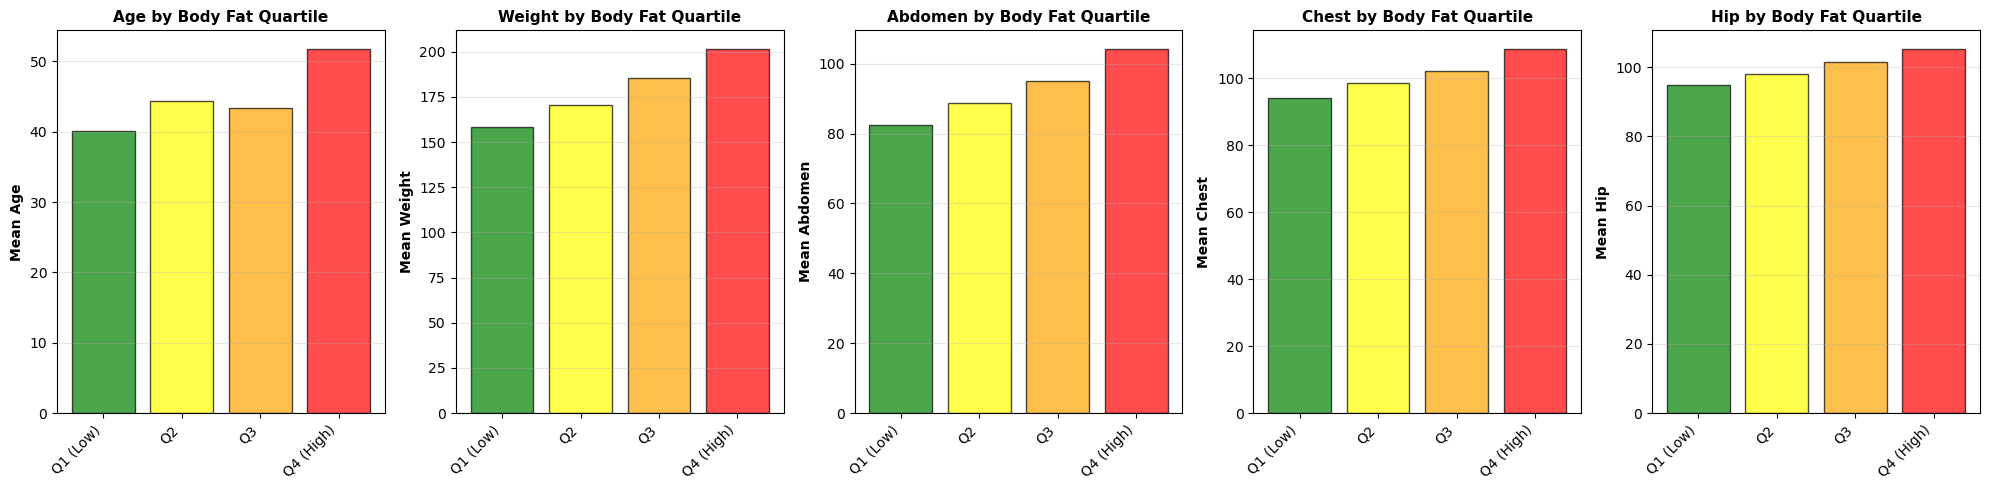

In [75]:
# ============================================================================
# 6. SUMMARY STATISTICS BY TARGET QUARTILES
# ============================================================================
print("\n" + "=" * 80)
print("TARGET DISTRIBUTION ANALYSIS")
print("=" * 80)

# Create target quartiles
df['target_quartile'] = pd.qcut(df['target'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])

# ============================================================================
# Table 1: Target Quartile Ranges
# ============================================================================
print("\n" + "=" * 80)
print("TARGET QUARTILE RANGES")
print("=" * 80)

quartile_ranges = df.groupby('target_quartile', observed=True)['target'].agg(['min', 'max', 'count']).reset_index()
quartile_ranges.columns = ['Quartile', 'Min Body Fat %', 'Max Body Fat %', 'Count']

# Display with styling
display(quartile_ranges.style.format({
    'Min Body Fat %': '{:.2f}',
    'Max Body Fat %': '{:.2f}',
    'Count': '{:.0f}'
}).background_gradient(subset=['Min Body Fat %', 'Max Body Fat %'], cmap='YlOrRd')
  .set_caption('Target Quartile Ranges')
  .set_table_styles([
      {'selector': 'caption', 
       'props': [('font-size', '14px'), ('font-weight', 'bold'), 
                 ('text-align', 'center'), ('padding', '10px')]},
      {'selector': 'th', 
       'props': [('background-color', '#4472C4'), ('color', 'white'), 
                ('font-weight', 'bold'), ('text-align', 'center')]},
      {'selector': 'td', 
       'props': [('text-align', 'center'), ('padding', '6px')]}
  ]))

# ============================================================================
# Table 2: Mean Values of Key Features by Target Quartile
# ============================================================================
print("\n" + "=" * 80)
print("MEAN VALUES OF KEY FEATURES BY TARGET QUARTILE")
print("=" * 80)

key_features_analysis = ['Age', 'Weight', 'Abdomen', 'Chest', 'Hip']
quartile_summary = df.groupby('target_quartile', observed=True)[key_features_analysis].mean().reset_index()
quartile_summary.columns = ['Quartile'] + key_features_analysis

# Display with styling
display(quartile_summary.style.format({
    'Age': '{:.2f}',
    'Weight': '{:.2f}',
    'Abdomen': '{:.2f}',
    'Chest': '{:.2f}',
    'Hip': '{:.2f}'
}).background_gradient(subset=key_features_analysis, cmap='YlOrRd', axis=0)
  .set_caption('Mean Values of Key Features by Target Quartile')
  .set_table_styles([
      {'selector': 'caption', 
       'props': [('font-size', '14px'), ('font-weight', 'bold'), 
                 ('text-align', 'center'), ('padding', '10px')]},
      {'selector': 'th', 
       'props': [('background-color', '#4472C4'), ('color', 'white'), 
                ('font-weight', 'bold'), ('text-align', 'center')]},
      {'selector': 'td', 
       'props': [('text-align', 'center'), ('padding', '6px')]}
  ]))

# Visualize
fig, axes = plt.subplots(1, len(key_features_analysis), figsize=(20, 5))
for i, feat in enumerate(key_features_analysis):
    quartile_means = df.groupby('target_quartile', observed=True)[feat].mean()  # Added observed=True
    axes[i].bar(range(len(quartile_means)), quartile_means.values, 
                color=['green', 'yellow', 'orange', 'red'], alpha=0.7, edgecolor='black')
    axes[i].set_xticks(range(len(quartile_means)))
    axes[i].set_xticklabels(quartile_means.index, rotation=45, ha='right')
    axes[i].set_ylabel(f'Mean {feat}', fontsize=10, fontweight='bold')
    axes[i].set_title(f'{feat} by Body Fat Quartile', fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()



AGE VS BODY FAT ANALYSIS


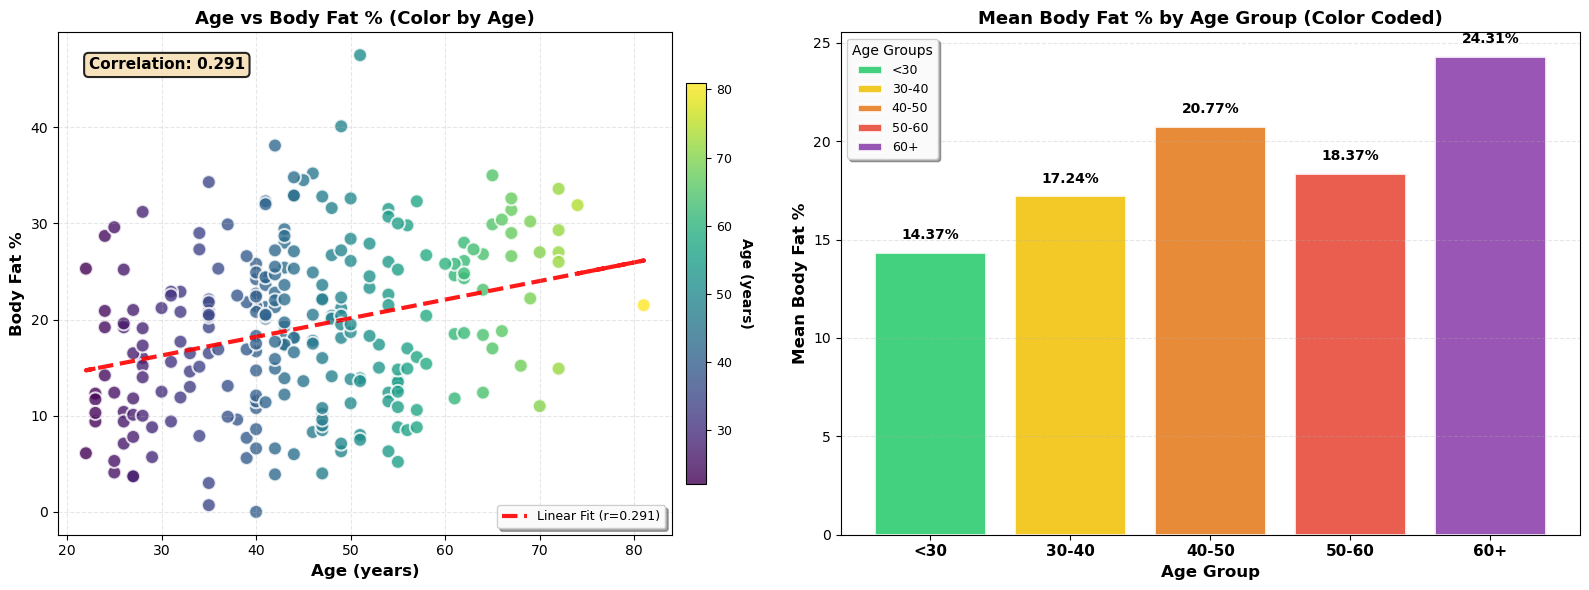


Mean body fat by age group:


,mean,std,count
age_group,,,
<30,14.368421,7.414489,38
30-40,17.244444,7.500658,54
40-50,20.767857,8.224342,84
50-60,18.373171,9.049835,41
60+,24.314285,6.485556,35


In [76]:
# ============================================================================
# 7. AGE ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("AGE VS BODY FAT ANALYSIS")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot with vibrant color coding by age
# First create age groups for color coding
df['age_group'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 60, 100], 
                         labels=['<30', '30-40', '40-50', '50-60', '60+'])

# Use vibrant colormap for scatter plot
scatter = axes[0].scatter(df['Age'], df['target'], 
                         c=df['Age'], cmap='viridis',  # Changed to viridis for vibrant colors
                         alpha=0.8, s=100, edgecolors='white', linewidth=1.5,
                         vmin=df['Age'].min(), vmax=df['Age'].max())

# Add regression line
z = np.polyfit(df['Age'], df['target'], 1)
p = np.poly1d(z)
axes[0].plot(df['Age'], p(df['Age']), "red", linestyle='--', 
            linewidth=3, alpha=0.9, label=f'Linear Fit (r={df["Age"].corr(df["target"]):.3f})', zorder=1)

axes[0].set_xlabel('Age (years)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Body Fat %', fontsize=12, fontweight='bold')
axes[0].set_title('Age vs Body Fat % (Color by Age)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, linestyle='--', zorder=0)
corr_age = df['Age'].corr(df['target'])
axes[0].text(0.05, 0.95, f'Correlation: {corr_age:.3f}', transform=axes[0].transAxes,
            fontsize=11, verticalalignment='top', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85, 
                     edgecolor='black', linewidth=1.5))
axes[0].legend(loc='lower right', fontsize=9, framealpha=0.95, fancybox=True, shadow=True)

# Add colorbar for age with vibrant colors
cbar = plt.colorbar(scatter, ax=axes[0], shrink=0.8, pad=0.02)
cbar.set_label('Age (years)', fontsize=10, fontweight='bold', rotation=270, labelpad=15)
cbar.ax.tick_params(labelsize=9)

# Age groups bar chart with color coding
age_group_means = df.groupby('age_group', observed=True)['target'].mean()

# Color code bars by age group with vibrant colors
bar_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']  # Vibrant: green, yellow, orange, red, purple
bars = axes[1].bar(range(len(age_group_means)), age_group_means.values,
           color=bar_colors, alpha=0.9, edgecolor='white', linewidth=2)

# Add value labels on top of bars
for i, (bar, value) in enumerate(zip(bars, age_group_means.values)):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{value:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold',
                color='black')

axes[1].set_xticks(range(len(age_group_means)))
axes[1].set_xticklabels(age_group_means.index, fontsize=11, fontweight='bold')
axes[1].set_ylabel('Mean Body Fat %', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age Group', fontsize=12, fontweight='bold')
axes[1].set_title('Mean Body Fat % by Age Group (Color Coded)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y', linestyle='--')

# Add legend for age groups
from matplotlib.patches import Rectangle
legend_elements = [Rectangle((0,0),1,1, facecolor=bar_colors[i], 
                             alpha=0.9, edgecolor='white', linewidth=2, 
                             label=group) for i, group in enumerate(age_group_means.index)]
axes[1].legend(handles=legend_elements, loc='upper left', fontsize=9, 
              framealpha=0.95, fancybox=True, shadow=True, title='Age Groups',
              title_fontsize=10)

plt.tight_layout()
plt.show()

# Print statistics table
print("\nMean body fat by age group:")
age_group_stats = df.groupby('age_group', observed=True)['target'].agg(['mean', 'std', 'count'])
display(age_group_stats.style.format({
    'mean': '{:.6f}',
    'std': '{:.6f}',
    'count': '{:.0f}'
}).background_gradient(subset=['mean'], cmap='YlOrRd')
  .set_caption('Mean Body Fat by Age Group')
  .set_table_styles([
      {'selector': 'caption', 
       'props': [('font-size', '14px'), ('font-weight', 'bold'), 
                 ('text-align', 'center'), ('padding', '10px')]},
      {'selector': 'th', 
       'props': [('background-color', '#4472C4'), ('color', 'white'), 
                ('font-weight', 'bold'), ('text-align', 'center')]},
      {'selector': 'td', 
       'props': [('text-align', 'center'), ('padding', '6px')]}
  ]))


BODY MEASUREMENTS SUMMARY


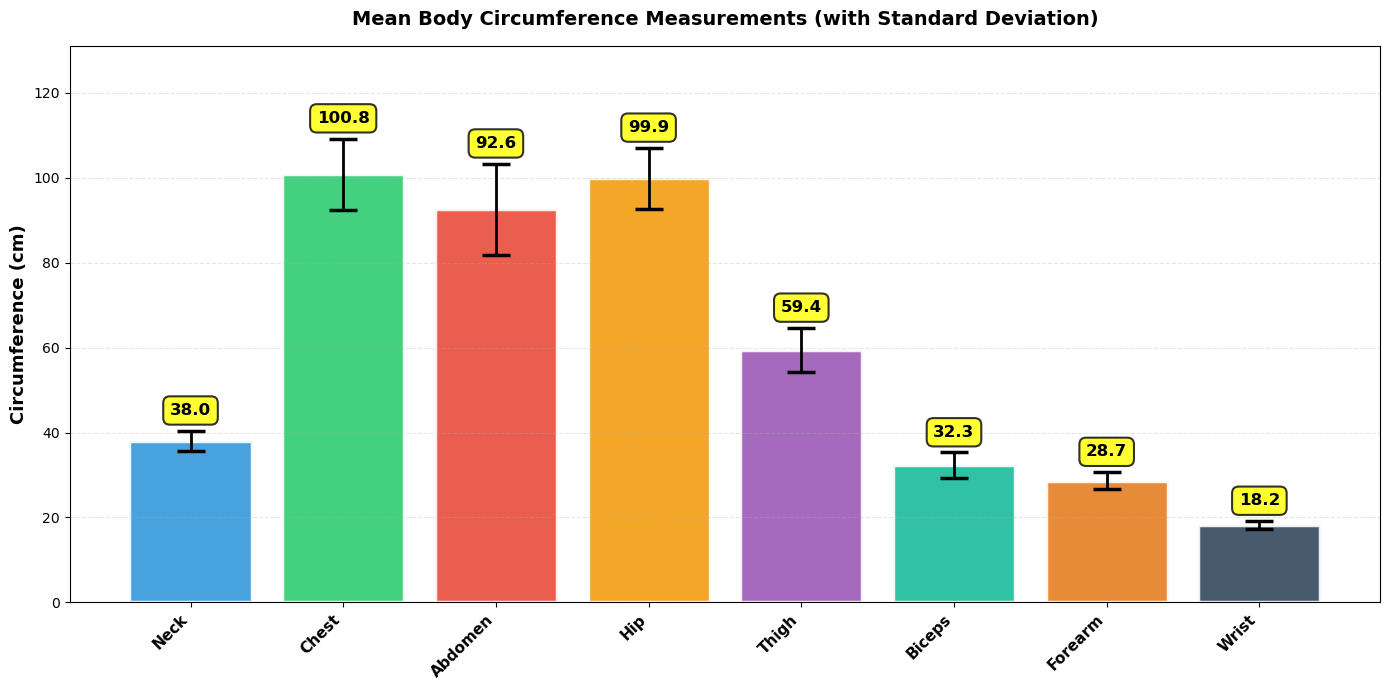

In [77]:
# ============================================================================
# 8. BODY MEASUREMENTS COMPARISON
# ============================================================================
print("\n" + "=" * 80)
print("BODY MEASUREMENTS SUMMARY")
print("=" * 80)

circumference_features = ['Neck', 'Chest', 'Abdomen', 'Hip', 'Thigh', 'Biceps', 'Forearm', 'Wrist']
circ_mean = df[circumference_features].mean()
circ_std = df[circumference_features].std()

fig, ax = plt.subplots(figsize=(14, 7))
x_pos = np.arange(len(circumference_features))

# Use vibrant colors
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

# Create bars with error bars (capthick should be in error_kw)
bars = ax.bar(x_pos, circ_mean.values, yerr=circ_std.values, 
              alpha=0.9, color=colors, edgecolor='white', linewidth=2.5, 
              capsize=10, error_kw={'elinewidth': 2, 'ecolor': 'black', 'capthick': 2.5})

# Add mean value labels on top of bars
for i, (bar, mean_val, std_val) in enumerate(zip(bars, circ_mean.values, circ_std.values)):
    # Position label above error bar
    label_y = bar.get_height() + std_val + 3
    
    ax.text(bar.get_x() + bar.get_width()/2, label_y,
            f'{mean_val:.1f}', 
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.8, 
                     edgecolor='black', linewidth=1.5))

ax.set_xticks(x_pos)
ax.set_xticklabels(circumference_features, rotation=45, ha='right', fontsize=11, fontweight='bold')
ax.set_ylabel('Circumference (cm)', fontsize=13, fontweight='bold')
ax.set_title('Mean Body Circumference Measurements (with Standard Deviation)', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Set y-axis limit to accommodate labels
ax.set_ylim(bottom=0, top=max(circ_mean.values + circ_std.values) * 1.2)

plt.tight_layout()
plt.show()

There isn't a single "classification regression" model. Classification and regression are different tasks, but some models have both versions.

## Models with both Classifier and Regressor versions

1. **Random Forest**
   - `RandomForestClassifier` (classification)
   - `RandomForestRegressor` (regression)
   - Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

2. **Support Vector Machines**
   - `SVC` (classification)
   - `SVR` (regression)
   - Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html

3. **Decision Trees**
   - `DecisionTreeClassifier` (classification)
   - `DecisionTreeRegressor` (regression)
   - Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

## Important note: Logistic Regression

**Logistic Regression** is a classification algorithm, not regression, despite the name:
- `LogisticRegression` (classification only)
- Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- Wikipedia: https://en.wikipedia.org/wiki/Logistic_regression

## For Problem 5 (regression)

Since Problem 5 asks for regression models for Problem 6 (predicting body fat percentage, a continuous value), use regressors, not classifiers.

Good regression choices:
- `LinearRegression`
- `Ridge` (Ridge Regression)
- `Lasso` (Lasso Regression)
- `ElasticNet`
- `RandomForestRegressor`
- `SVR` (Support Vector Regression)
- `DecisionTreeRegressor`

If you want a model that can handle both, `RandomForestRegressor` is a solid choice.